# GFM Embeddings for Spatial LST Prediction

Do embeddings from a geospatial foundation model carry information about land surface
temperature that traditional spectral indices miss?

**Study area** Flanders, Belgium, with an out-of-region test in Wallonia  
**Target** Land surface temperature, Landsat 8/9 Collection 2 Level 2, summer 2022  
**Model** Prithvi-EO-2.0-300M-TL as a frozen feature extractor, never fine-tuned  
**Benchmark** Random Forest regression  
**Evaluation** Spatial `GroupKFold` grouped on tile, plus transfer to an unseen region

This notebook regenerates every artefact it uses, so it runs against an empty directory. That
path has prerequisites:

- **A Google Earth Engine account** with a cloud project enabled. Free for research use. Its
  project id goes in `GEE_PROJECT` in Section 2.
- **A GPU runtime.** The backbone runs on CPU, but extraction then takes hours instead of about
  half an hour.
- **Roughly 100 MB** of disk for the cached artefacts.

If `patches.csv` and `embeddings.npy` are already present, none of that applies. Extraction is
skipped, no Earth Engine call is made, and everything else runs on CPU in a few minutes.

Point the notebook at a directory with the `GFM_LST_PROJECT_DIR` environment variable. Without
it, Colab uses a Drive folder and a local run uses `./data`.

## Data sources

| Source | Used for |
|---|---|
| `NASA/HLS/HLSS30/v002` | six-band surface reflectance composite |
| `LANDSAT/LC08/C02/T1_L2` and `LC09` | land surface temperature target |
| `FAO/GAUL/2015/level1` | Flanders and Wallonia administrative boundaries |
| [Prithvi-EO-2.0-300M-TL](https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL) | embedding backbone |

All openly accessible. The backbone is used as a fixed feature extractor, so reproducing this
needs one forward pass per tile and no training compute.

## 0. Setup

In [1]:
import os
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore", category=FutureWarning)

# torch, terratorch, earthengine-api and geemap are needed only to build the dataset from
# scratch, so they are installed and imported inside the extraction function in Section 2.
# A run that finds cached data never pays for them, and anyone who only wants to check the
# analysis does not need an Earth Engine account to do it.

ENVIRONMENT = {"python": sys.version.split()[0],
               **{m.__name__: m.__version__ for m in (np, pd, sklearn, matplotlib, sns)}}

for name, version in ENVIRONMENT.items():
    print(f"{name} {version}")

python 3.12.13
numpy 2.5.2
pandas 2.2.2
sklearn 1.6.1
matplotlib 3.10.0
seaborn 0.13.2


In [2]:
def resolve_project_dir():
    """Where cached artefacts live. Explicit setting wins, then Colab Drive, then ./data."""
    if os.environ.get("GFM_LST_PROJECT_DIR"):
        return Path(os.environ["GFM_LST_PROJECT_DIR"])
    if "google.colab" in sys.modules:
        from google.colab import drive
        drive.mount("/content/drive")
        return Path("/content/drive/MyDrive/GFM_LST_Flanders")
    return Path("data")


PROJECT_DIR = resolve_project_dir()
RESULT_DIR = PROJECT_DIR / "results"
MODEL_DIR = PROJECT_DIR / "models"
FIGURE_DIR = PROJECT_DIR / "figures"
REFERENCE_DIR = PROJECT_DIR / "reference"  # third-party files downloaded once and kept

for d in (PROJECT_DIR, RESULT_DIR, MODEL_DIR, FIGURE_DIR, REFERENCE_DIR):
    d.mkdir(parents=True, exist_ok=True)

existing = sorted(p.name for p in PROJECT_DIR.rglob("*") if p.is_file())
print(f"Project directory: {PROJECT_DIR}")
print(f"{len(existing)} file(s) already present" if existing
      else "Directory is empty; every artefact will be built from scratch")

# Tree-building details in scikit-learn change between releases, so the same seed on a different
# version can produce a different forest. Recording what was installed makes a mismatch visible
# instead of leaving it to be discovered as an unexplained difference in the numbers.
json.dump(ENVIRONMENT, open(PROJECT_DIR / "environment.json", "w"), indent=2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/GFM_LST_Flanders
25 file(s) already present


In [3]:
FORCE_RECOMPUTE = False  # True rebuilds every cached artefact, ignoring what is on disk

RANDOM_SEED = 42
N_SPLITS = 5

GROUP_COLUMN = "tile_id"
TARGET = "lst_c"
TRADITIONAL_FEATURES = ["ndvi", "ndbi", "albedo"]

GFM_DIM = 1024  # output width of the Prithvi-EO-2.0-300M backbone
PCA_SWEEP = [5, 15, 30, 50, 100, 200, GFM_DIM]  # GFM_DIM means no compression

RF_PARAMS = dict(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")

print(f"seed {RANDOM_SEED}, {N_SPLITS} folds grouped on '{GROUP_COLUMN}', target '{TARGET}'")
print(f"traditional features: {TRADITIONAL_FEATURES}")
print(f"PCA sweep: {PCA_SWEEP}")
print(f"forest: {RF_PARAMS}")
if FORCE_RECOMPUTE:
    print("\nFORCE_RECOMPUTE is on; cached artefacts will be rebuilt")

seed 42, 5 folds grouped on 'tile_id', target 'lst_c'
traditional features: ['ndvi', 'ndbi', 'albedo']
PCA sweep: [5, 15, 30, 50, 100, 200, 1024]
forest: {'n_estimators': 300, 'min_samples_leaf': 3, 'n_jobs': -1, 'random_state': 42}


In [4]:
def _load(path):
    if path.suffix == ".csv":
        return pd.read_csv(path)
    if path.suffix == ".npy":
        return np.load(path)
    if path.suffix == ".joblib":
        return joblib.load(path)
    raise ValueError(f"no loader for {path.suffix}")


def _save(obj, path):
    if path.suffix == ".csv":
        obj.to_csv(path, index=False)
    elif path.suffix == ".npy":
        np.save(path, obj)
    elif path.suffix == ".joblib":
        joblib.dump(obj, path)
    else:
        raise ValueError(f"no writer for {path.suffix}")


def cached(outputs, compute):
    """Return a previously saved result, or run compute() and save it.

    `outputs` maps a name to a path; `compute` returns a dict with those same keys. Each group
    is all-or-nothing: if any file is missing the whole group is recomputed. Reusing one file
    from an old run alongside a freshly computed sibling is how results quietly stop matching
    each other, and a partial group is far more likely to be an interrupted run than a
    deliberate state worth preserving.
    """
    outputs = {k: Path(v) for k, v in outputs.items()}
    names = ", ".join(p.name for p in outputs.values())

    if all(p.exists() for p in outputs.values()) and not FORCE_RECOMPUTE:
        print(f"cached: {names}")
        return {k: _load(p) for k, p in outputs.items()}

    print(f"computing: {names}")
    result = compute()
    for k, p in outputs.items():
        p.parent.mkdir(parents=True, exist_ok=True)
        _save(result[k], p)
    print(f"saved: {names}")
    return result

## 1. Study design

Stated before any data is loaded, so that every result below can point back to a decision made
here rather than to a choice buried inside a modelling cell.

### Questions

1. Can frozen foundation-model embeddings predict patch-level land surface temperature?
2. Do they outperform NDVI, NDBI and albedo, the indices normally used for this?
3. Does combining embeddings with those indices beat either on its own?
4. Does compressing the embedding with PCA help or hurt?
5. Does a model fitted in one region say anything useful about a region it has never seen?

Each results section answers one of these and names which.

### Three feature conditions

One Random Forest specification, three feature sets. Holding the learner fixed means any
difference between conditions is attributable to the features.

| Condition | Features | Dimensionality |
|---|---|---|
| `traditional` | NDVI, NDBI, albedo | 3 |
| `gfm_full` | Prithvi embedding, standardised | 1024 |
| `combined` | both | 1027 |

### Why cross-validation has to be spatial

The sampling design nests patches inside tiles. Each tile covers 6.72 km and is cut into a
14 x 14 grid, so up to 196 patches of 480 m come from one tile. Those patches share a land
cover context and a single seasonal composite, and sit close enough together to be spatially
autocorrelated.

Under a random K-fold, some patches from a tile land in training while others from that same
tile land in test. The model is then scored partly on conditions it has already seen, which
raises the reported R² without that accuracy transferring to any new location. `GroupKFold` on
tile sends every patch of a tile entirely to one side of a fold.

The consequence worth carrying forward is that the number of independent spatial units is the
number of tiles, not the number of patches. Section 11 returns to what that means for how much
weight the fold-level statistics can bear.

### PCA is a question

A 1024-dimensional embedding is not guaranteed to compress without discarding exactly the
directions that predict the target. Section 6 measures whether compression helps rather than
assuming it does, and fits every PCA inside a training fold only. No PCA is ever fitted across
the full dataset, so no leaky component columns exist anywhere for a later section to
accidentally pick up.

### Where generalisation is actually tested

Spatial cross-validation holds out tiles, but every fold is still Flemish landscape under the
same summer composite. Section 10 therefore applies the finished model to Wallonia, a region
with more forest and relief and less dense urban fabric, with no representation in training at
all.

## 2. Building the dataset

Everything downstream reads two artefacts: a patch-level table and a row-aligned embedding
matrix. If they are already in the project directory they are loaded as they are. If not, they
are built from Earth Engine and a frozen backbone by the function below.

### What extraction does

Tile centres are drawn at random from a regular grid clipped to the Flanders administrative
boundary. Each tile is 224 x 224 pixels at 30 m, its centre snapped to the UTM grid so patch
boundaries fall on pixel edges instead of straddling them.

Per tile, two summer-2022 median composites are pulled. A six-band HLS S30 composite supplies
the imagery; a merged Landsat 8/9 Collection 2 Level 2 composite supplies the temperature
target. Both are masked for cloud, cloud shadow, cirrus and water before compositing.

The reflectance stack is normalised with the backbone's own statistics and passed through
Prithvi once. Its patch tokens reshape into a 14 x 14 grid, giving one 1024-dimensional vector
per patch. NDVI, NDBI, albedo and temperature are averaged over the same 16 x 16 pixel
footprint, so features and target describe identical ground.

A patch whose masking leaves any of those four averages undefined is dropped rather than
imputed, which is why tiles return slightly fewer than the full 196.

In [5]:
GEE_PROJECT = 'gfms-505010'  # Set this to your own Earth Engine cloud project id, or export GEE_PROJECT before starting.
# Left unset deliberately: a hard-coded id would send someone else's first run into an
# authentication failure against a project they cannot access, reported as an error that
# explains nothing about the real cause.

DATE_START, DATE_END = "2022-06-01", "2022-08-31"
CLOUD_MAX_PCT = 50

TILE_PX, NATIVE_SCALE_M = 224, 30
PATCH_PX = 16
N_PATCH_SIDE = TILE_PX // PATCH_PX
TILE_SIZE_M = TILE_PX * NATIVE_SCALE_M
PATCHES_PER_TILE = N_PATCH_SIDE ** 2

UTM_CRS = "EPSG:32631"
N_TILES_TARGET = 30

REGIONS = {
    "flanders": {"bbox": [2.54, 50.68, 5.92, 51.51],
                 "gaul_names": ["Vlaams Gewest", "Flemish Region", "Flanders"]},
    "wallonia": {"bbox": [2.84, 49.49, 6.41, 50.81],
                 "gaul_names": ["Region Wallonne", "Walloon Region", "Wallonia"]},
}

HLS_BANDS = ["B2", "B3", "B4", "B8A", "B11", "B12"]  # blue, green, red, NIR-narrow, SWIR1, SWIR2
HF_REPO = "ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL"

print(f"{TILE_PX}px tiles at {NATIVE_SCALE_M}m = {TILE_SIZE_M/1000:.2f} km, "
      f"cut into {N_PATCH_SIDE}x{N_PATCH_SIDE} patches of {PATCH_PX*NATIVE_SCALE_M}m")
print(f"target: {N_TILES_TARGET} tiles, up to {PATCHES_PER_TILE} patches each")
print(f"Earth Engine project: {GEE_PROJECT or 'not set (only needed for a cold start)'}")

224px tiles at 30m = 6.72 km, cut into 14x14 patches of 480m
target: 30 tiles, up to 196 patches each
Earth Engine project: gfms-505010


In [6]:
def build_composites(ee, region):
    """Cloud-masked median composites for reflectance and surface temperature."""

    def mask_hls(img):
        fmask = img.select("Fmask").toInt()
        bad = (fmask.bitwiseAnd(1 << 1).neq(0)          # cloud
               .Or(fmask.bitwiseAnd(1 << 2).neq(0))     # adjacent to cloud
               .Or(fmask.bitwiseAnd(1 << 3).neq(0))     # cloud shadow
               .Or(fmask.bitwiseAnd(1 << 5).neq(0)))    # water
        return img.updateMask(bad.Not())

    def mask_landsat(img):
        qa = img.select("QA_PIXEL")
        # Cirrus is masked alongside opaque cloud. Thin high cloud passes enough visible light
        # to look clear in reflectance while still depressing the thermal signal, so leaving it
        # in produces patches that read as anomalously cool for no surface reason.
        bad = (qa.bitwiseAnd(1 << 1).neq(0)             # dilated cloud
               .Or(qa.bitwiseAnd(1 << 2).neq(0))        # cirrus
               .Or(qa.bitwiseAnd(1 << 3).neq(0))        # cloud
               .Or(qa.bitwiseAnd(1 << 4).neq(0))        # cloud shadow
               .Or(qa.bitwiseAnd(1 << 7).neq(0)))       # water
        # Collection 2 Level 2 scale and offset, converted from kelvin to celsius.
        lst_c = (img.select("ST_B10").multiply(0.00341802).add(149.0)
                 .subtract(273.15).rename("LST_C"))
        return lst_c.updateMask(bad.Not())

    hls = (ee.ImageCollection("NASA/HLS/HLSS30/v002")
           .filterDate(DATE_START, DATE_END).filterBounds(region)
           .filter(ee.Filter.lt("CLOUD_COVERAGE", CLOUD_MAX_PCT))
           .map(mask_hls).select(HLS_BANDS))

    landsat = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
               .merge(ee.ImageCollection("LANDSAT/LC09/C02/T1_L2"))
               .filterDate(DATE_START, DATE_END).filterBounds(region)
               .filter(ee.Filter.lt("CLOUD_COVER", CLOUD_MAX_PCT))
               .map(mask_landsat))

    print(f"  {hls.size().getInfo()} HLS scenes, {landsat.size().getInfo()} Landsat scenes")

    return (hls.median().reproject(crs=UTM_CRS, scale=NATIVE_SCALE_M),
            landsat.select("LST_C").median().reproject(crs=UTM_CRS, scale=NATIVE_SCALE_M))


def compute_indices(reflectance):
    """NDVI, NDBI and broadband albedo from a six-band reflectance stack.

    Normalised ratios are formed only where the denominator is safely away from zero. Elsewhere
    the result stays NaN so the affected patch is dropped later, rather than being filled with
    a value that would look like a measurement.
    """
    clipped = np.clip(reflectance, 0.0, 1.0)
    blue, green, red, nir, swir1, swir2 = [clipped[:, :, i] for i in range(6)]

    eps = 0.01
    ndvi_denom, ndbi_denom = nir + red, swir1 + nir
    ndvi = np.clip(np.where(np.abs(ndvi_denom) > eps,
                            (nir - red) / (ndvi_denom + 1e-9), np.nan), -1, 1)
    ndbi = np.clip(np.where(np.abs(ndbi_denom) > eps,
                            (swir1 - nir) / (ndbi_denom + 1e-9), np.nan), -1, 1)
    # Liang (2001) narrowband-to-broadband coefficients.
    albedo = (0.356*blue + 0.130*red + 0.373*nir
              + 0.085*swir1 + 0.072*swir2 - 0.0018)

    return clipped, ndvi, ndbi, albedo


def resolve_norm_stats():
    """The backbone's own reflectance mean and standard deviation, read from its model config.

    Normalising with the wrong statistics degrades every embedding without raising anything, so
    which source was used is returned alongside the numbers and written into the run manifest.
    The fallback values are transcribed from the published model card and are used only when the
    config cannot be read.
    """
    fallback_mean = np.array([1087., 1342., 1433., 2734., 1958., 1363.]) / 10000.0
    fallback_std = np.array([2248., 2179., 2178., 1850., 1242., 1049.]) / 10000.0

    def nested(d, dotted):
        for part in dotted.split("."):
            if not isinstance(d, dict) or part not in d:
                return None
            d = d[part]
        return d

    try:
        from huggingface_hub import hf_hub_download
        cfg = json.load(open(hf_hub_download(repo_id=HF_REPO, filename="config.json")))
        # The key names have varied across releases, so several spellings are tried.
        for mean_key, std_key in [("mean", "std"), ("means", "stds"),
                                  ("data_mean", "data_std"),
                                  ("pretrained_cfg.mean", "pretrained_cfg.std")]:
            m, s = nested(cfg, mean_key), nested(cfg, std_key)
            if m is not None and s is not None and len(m) == 6 and len(s) == 6:
                m, s = np.array(m, float), np.array(s, float)
                if m.max() > 10:  # stored as scaled integers rather than reflectance
                    m, s = m / 10000.0, s / 10000.0
                return m, s, f"model config ({mean_key}/{std_key})"
    except Exception as e:
        print(f"  could not read config.json: {type(e).__name__}: {e}")

    print("  WARNING: falling back to statistics transcribed from the model card")
    return fallback_mean, fallback_std, "model card fallback"

In [7]:
def extract_region(region_key, n_tiles, seed):
    """Build a patch table and embedding matrix for one region, from Earth Engine upward.

    Written to work for any region in REGIONS so that the training set and the out-of-region test
    in Section 10 come from one code path. If the two were extracted by separate code, a
    difference in results between regions could be a difference in extraction rather than in
    landscape.
    """
    if not GEE_PROJECT:
        raise RuntimeError(
            "Extraction needs a Google Earth Engine cloud project. Set GEE_PROJECT in the "
            "configuration cell above, or export it as an environment variable, then re-run. "
            "To reproduce only the analysis, place patches.csv and embeddings.npy in the "
            "project directory instead; no Earth Engine access is then required."
        )

    # Install only what is actually absent. Nothing is version-pinned here: terratorch declares
    # its own requirements, and pinning one of them independently gives pip a conflict it cannot
    # resolve. The install is allowed to fail quietly so that the import below raises instead,
    # which names the missing module rather than reporting a dependency resolver's exit code.
    import importlib.util
    dependencies = {"terratorch": "terratorch", "ee": "earthengine-api", "geemap": "geemap",
                    "rasterio": "rasterio", "huggingface_hub": "huggingface_hub"}
    missing = [pkg for module, pkg in dependencies.items()
               if importlib.util.find_spec(module) is None]
    if missing:
        import subprocess
        print(f"  installing {', '.join(missing)}")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=False)

    import torch
    import ee
    import geemap
    from terratorch.registry import BACKBONE_REGISTRY

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cpu":
        print("  no GPU available; extraction will be slow")

    try:
        ee.Number(1).getInfo()
    except Exception:
        ee.Authenticate()
        ee.Initialize(project=GEE_PROJECT)

    backbone = BACKBONE_REGISTRY.build("prithvi_eo_v2_300_tl", pretrained=True).to(device).eval()
    for p in backbone.parameters():
        p.requires_grad = False
    print(f"  backbone: {sum(p.numel() for p in backbone.parameters()):,} frozen parameters")

    spec = REGIONS[region_key]
    admin = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(ee.Filter.eq("ADM0_NAME", "Belgium"))
    matched = admin.filter(ee.Filter.inList("ADM1_NAME", spec["gaul_names"]))
    if matched.aggregate_array("ADM1_NAME").getInfo():
        region, region_source = matched.geometry(maxError=100), "FAO GAUL administrative boundary"
    else:
        # The bounding box spills into sea and across the national border, so this path is a
        # degraded run rather than an equivalent one. Recorded so results are never compared
        # against a boundary-clipped run without that difference being visible.
        region = ee.Geometry.Rectangle(spec["bbox"])
        region_source = "bounding box fallback, boundary lookup failed"
    print(f"  region: {region_source}")

    hls_composite, lst_composite = build_composites(ee, region)
    mean_refl, std_refl, norm_source = resolve_norm_stats()
    print(f"  normalisation: {norm_source}")

    # A dedicated generator rather than the global numpy state, so tile selection depends only
    # on this seed and not on whatever else happened to draw random numbers first.
    rng = np.random.default_rng(seed)
    west, south, east, north = spec["bbox"]
    lat_step = TILE_SIZE_M / 111320
    lon_step = TILE_SIZE_M / (111320 * np.cos(np.radians((south + north) / 2)))
    grid = [(lat, lon)
            for lat in np.arange(south + lat_step/2, north, lat_step)
            for lon in np.arange(west + lon_step/2, east, lon_step)]

    points = ee.FeatureCollection([ee.Feature(ee.Geometry.Point([lon, lat]), {"i": i})
                                   for i, (lat, lon) in enumerate(grid)])
    inside = [grid[int(i)] for i in points.filterBounds(region).aggregate_array("i").getInfo()]
    print(f"  {len(inside)} of {len(grid)} grid cells fall inside the region")

    if len(inside) < n_tiles:
        raise RuntimeError(f"only {len(inside)} candidate tiles available, {n_tiles} requested")
    centers = [inside[i] for i in rng.choice(len(inside), n_tiles, replace=False)]

    def tile_rect(lat, lon):
        # Snapping the centre to the 30 m grid keeps every patch boundary on a pixel edge, so a
        # patch mean averages whole pixels rather than resampled fractions of neighbours.
        x, y = ee.Geometry.Point([lon, lat]).transform(UTM_CRS, 1).coordinates().getInfo()
        x = round(x / NATIVE_SCALE_M) * NATIVE_SCALE_M
        y = round(y / NATIVE_SCALE_M) * NATIVE_SCALE_M
        half = TILE_SIZE_M / 2
        return ee.Geometry.Rectangle([x - half, y - half, x + half, y + half], UTM_CRS, False)

    def fetch(composite, bands, rect):
        # Zero is Earth Engine's no-data fill here, so it becomes NaN rather than being read as
        # a real reflectance or a 0 degC surface.
        arr = geemap.ee_to_numpy(composite, bands=bands, region=rect)
        return None if arr is None else np.where(arr == 0.0, np.nan, arr)

    def embed(reflectance):
        normalised = np.nan_to_num((reflectance - mean_refl) / std_refl, nan=0.0)
        tensor = torch.from_numpy(normalised).permute(2, 0, 1).unsqueeze(0).float().to(device)
        with torch.no_grad():
            feats = (backbone.forward_features(tensor)
                     if hasattr(backbone, "forward_features") else backbone(tensor))
        # Last hidden layer, class token dropped, patch tokens restored to their spatial layout.
        return feats[-1][:, 1:, :][0].reshape(N_PATCH_SIDE, N_PATCH_SIDE, -1).cpu().numpy()

    rows, vectors, failures = [], [], []

    for tile_id, (lat, lon) in enumerate(centers):
        try:
            rect = tile_rect(lat, lon)
            reflectance = fetch(hls_composite, HLS_BANDS, rect)
            temperature = fetch(lst_composite, ["LST_C"], rect)

            if reflectance is None or temperature is None or reflectance.shape[:2] != (TILE_PX, TILE_PX):
                failures.append({"tile_id": tile_id, "reason": "empty or unexpected shape"})
                continue

            clipped, ndvi, ndbi, albedo = compute_indices(reflectance)
            grid_embeddings = embed(clipped)
            lst_2d = temperature[:, :, 0]
            kept = 0

            for r in range(N_PATCH_SIDE):
                for c in range(N_PATCH_SIDE):
                    window = (slice(r*PATCH_PX, (r+1)*PATCH_PX),
                              slice(c*PATCH_PX, (c+1)*PATCH_PX))
                    values = {}
                    for name, layer in [("ndvi", ndvi), ("ndbi", ndbi),
                                        ("albedo", albedo), ("lst_c", lst_2d)]:
                        block = layer[window]
                        values[name] = np.nan if np.all(np.isnan(block)) else np.nanmean(block)
                    if any(np.isnan(v) for v in values.values()):
                        continue
                    rows.append({"tile_id": tile_id, "patch_row": r, "patch_col": c,
                                 "tile_center_lat": lat, "tile_center_lon": lon, **values})
                    vectors.append(grid_embeddings[r, c, :])
                    kept += 1

            print(f"  tile {tile_id:02d}: {kept}/{PATCHES_PER_TILE} patches kept")
        except Exception as e:
            failures.append({"tile_id": tile_id, "reason": f"{type(e).__name__}: {e}"})

    if not rows:
        raise RuntimeError("no patches assembled; see the per-tile messages above")
    if failures:
        print(f"  {len(failures)} tile(s) failed: {failures}")

    manifest = {"region": region_key, "region_source": region_source,
                "normalisation_source": norm_source, "dates": [DATE_START, DATE_END],
                "cloud_max_pct": CLOUD_MAX_PCT, "tiles_requested": n_tiles,
                "tiles_failed": failures, "seed": seed, "backbone": HF_REPO}
    json.dump(manifest, open(PROJECT_DIR / f"{region_key}_manifest.json", "w"), indent=2)

    return {"patches": pd.DataFrame(rows), "embeddings": np.stack(vectors, axis=0)}


flanders = cached(
    {"patches": PROJECT_DIR / "patches.csv",
     "embeddings": PROJECT_DIR / "embeddings.npy"},
    lambda: extract_region("flanders", N_TILES_TARGET, RANDOM_SEED),
)

patches, embeddings = flanders["patches"], flanders["embeddings"]

cached: patches.csv, embeddings.npy


In [8]:
if len(patches) != embeddings.shape[0]:
    raise ValueError(f"row mismatch: {len(patches)} patches, {embeddings.shape[0]} embeddings")
if embeddings.shape[1] != GFM_DIM:
    raise ValueError(f"expected {GFM_DIM}-dim embeddings, got {embeddings.shape[1]}")

print(f"{len(patches):,} patches across {patches[GROUP_COLUMN].nunique()} tiles")
print(f"embeddings: {embeddings.shape}")

COLUMN_NOTES = {
    "tile_id": "tile the patch belongs to",
    "patch_row": "row within the tile's 14x14 patch grid",
    "patch_col": "column within the tile's 14x14 patch grid",
    "tile_center_lat": "tile centroid latitude, EPSG:4326",
    "tile_center_lon": "tile centroid longitude, EPSG:4326",
    "ndvi": "normalised difference vegetation index",
    "ndbi": "normalised difference built-up index",
    "albedo": "broadband albedo",
    "lst_c": "target, land surface temperature in degrees celsius",
}

pd.DataFrame({"dtype": patches.dtypes.astype(str),
              "missing": patches.isna().sum(),
              "meaning": [COLUMN_NOTES.get(c, "") for c in patches.columns]})

5,845 patches across 30 tiles
embeddings: (5845, 1024)


,dtype,missing,meaning
tile_id,int64,0,tile the patch belongs to
patch_row,int64,0,row within the tile's 14x14 patch grid
patch_col,int64,0,column within the tile's 14x14 patch grid
tile_center_lat,float64,0,"tile centroid latitude, EPSG:4326"
tile_center_lon,float64,0,"tile centroid longitude, EPSG:4326"
ndvi,float64,0,normalised difference vegetation index
ndbi,float64,0,normalised difference built-up index
albedo,float64,0,broadband albedo
lst_c,float64,0,"target, land surface temperature in degrees ce..."


In [9]:
per_tile = patches.groupby(GROUP_COLUMN).size()
row_norms = np.linalg.norm(embeddings, axis=1)

# Nothing here repairs or removes anything, only counts, so these numbers can be quoted as they
# stand. A tile short of the full 196 is expected wherever masking left a patch with no valid
# pixels. An all-zero embedding row would mean the backbone returned nothing for a patch that
# did survive masking, which the row count alone would never reveal.
print(f"patches per tile: {per_tile.min()} to {per_tile.max()}, "
      f"median {per_tile.median():.0f}, out of a possible {PATCHES_PER_TILE}")
print(f"duplicate tile/row/column keys: {patches.duplicated([GROUP_COLUMN, 'patch_row', 'patch_col']).sum()}")
print(f"rows with a missing value: {patches.isna().any(axis=1).sum()}")
print(f"non-finite values in embeddings: {int((~np.isfinite(embeddings)).sum())}")
print(f"all-zero embedding rows: {int((row_norms == 0).sum())}")
print(f"embedding row norms: {row_norms.min():.1f} to {row_norms.max():.1f}")

print()
print(f"{TARGET}: {patches[TARGET].min():.2f} to {patches[TARGET].max():.2f} degC, "
      f"mean {patches[TARGET].mean():.2f}, sd {patches[TARGET].std():.2f}")
for col in TRADITIONAL_FEATURES:
    print(f"{col}: {patches[col].min():.3f} to {patches[col].max():.3f}, "
          f"mean {patches[col].mean():.3f}")

patches per tile: 165 to 196, median 196, out of a possible 196
duplicate tile/row/column keys: 0
rows with a missing value: 0
non-finite values in embeddings: 0
all-zero embedding rows: 0
embedding row norms: 23.2 to 26.5

lst_c: 21.30 to 46.61 degC, mean 30.83, sd 2.84
ndvi: 0.029 to 0.887, mean 0.614
ndbi: -0.460 to 0.221, mean -0.182
albedo: 0.053 to 0.248, mean 0.165


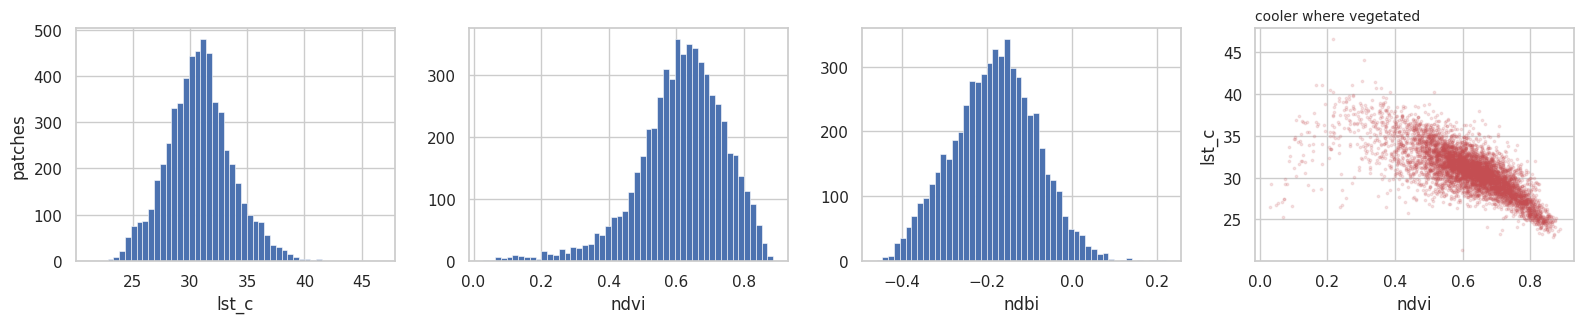

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))

for ax, col in zip(axes, [TARGET, "ndvi", "ndbi"]):
    ax.hist(patches[col], bins=50, color="#4C72B0", edgecolor="white", linewidth=0.4)
    ax.set_xlabel(col)
axes[0].set_ylabel("patches")

axes[3].scatter(patches["ndvi"], patches[TARGET], s=3, alpha=0.15, color="#C44E52")
axes[3].set_xlabel("ndvi")
axes[3].set_ylabel(TARGET)
axes[3].set_title("cooler where vegetated", fontsize=10, loc="left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "data_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Spatial structure

Section 1 argued that cross-validation has to hold out whole tiles. This section checks that the
premise behind that argument actually holds here, rather than assuming it.

Four things are worth establishing before any model is fitted: where the tiles sit relative to
each other, what a single tile contains, what neighbouring tiles look like on real imagery, and
how much of the variation in temperature is between tiles rather than within them.

The administrative outline and the satellite basemap below are context, not evidence. They come
from third-party services and are cached after one download. If either is unavailable the
figures still render without them, and no number in this notebook changes.

In [11]:
# geopandas and contextily are used only by the maps in this section and Section 4, so they are
# resolved here rather than being made a dependency of the whole notebook.
try:
    import geopandas as gpd
    import contextily as cx
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "geopandas", "contextily"], check=True)
    import geopandas as gpd
    import contextily as cx

import urllib.request
import matplotlib.patches as mpatches

DRAW_BASEMAPS = True  # False skips both third-party layers and every figure still renders

# Region names vary by language and by dataset vintage, so each region is matched against a list
# of aliases rather than one exact string. Whichever column carries the name is found the same
# way, since the field has been called different things across geoBoundaries releases.
REGION_ALIASES = {
    "flanders": ["flanders", "vlaanderen", "flemish", "vlaams", "flamande"],
    "wallonia": ["wallonia", "wallonie", "walloon", "waals", "wallonne"],
    "brussels": ["brussels", "bruxelles", "brussel"],
}


def load_belgium_regions():
    """First-level administrative boundaries for Belgium, downloaded once and cached.

    Source is geoBoundaries gbOpen, CC-BY 4.0 (Runfola et al. 2020). Used only to draw an
    outline behind the tile maps.
    """
    path = REFERENCE_DIR / "belgium_adm1.geojson"

    if not path.exists():
        api = "https://www.geoboundaries.org/api/current/gbOpen/BEL/ADM1/"
        with urllib.request.urlopen(api, timeout=60) as r:
            meta = json.load(r)
        with urllib.request.urlopen(meta["gjDownloadURL"], timeout=180) as r:
            path.write_bytes(r.read())
        print(f"downloaded Belgium ADM1 boundaries to {path.name}")

    gdf = gpd.read_file(path)
    name_col = next((c for c in ("shapeName", "name", "NAME_1", "ADM1_NAME")
                     if c in gdf.columns), None)
    if name_col is None:
        raise KeyError(f"no recognisable name column in {list(gdf.columns)}")

    def classify(value):
        text = str(value).lower()
        return next((k for k, aliases in REGION_ALIASES.items()
                     if any(a in text for a in aliases)), None)

    gdf["region_key"] = gdf[name_col].map(classify)
    return gdf


if DRAW_BASEMAPS:
    try:
        belgium = load_belgium_regions()
        flanders_outline = belgium[belgium.region_key == "flanders"]
        print(f"boundaries ready: {list(belgium.region_key.dropna())}")
    except Exception as e:
        belgium = flanders_outline = None
        print(f"boundary outline unavailable ({type(e).__name__}: {e}); "
              f"maps will render without it")
else:
    belgium = flanders_outline = None

boundaries ready: ['brussels', 'flanders', 'wallonia']


In [12]:
tiles = (patches.groupby(GROUP_COLUMN)
         .agg(lat=("tile_center_lat", "first"),
              lon=("tile_center_lon", "first"),
              n_patches=("lst_c", "size"),
              lst_mean=("lst_c", "mean"),
              lst_sd=("lst_c", "std"),
              ndvi_mean=("ndvi", "mean"),
              ndbi_mean=("ndbi", "mean"),
              albedo_mean=("albedo", "mean"))
         .reset_index())


def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * r * np.arcsin(np.sqrt(a))


# Pairwise separation between tile centres. The nearest-neighbour distances matter more than the
# mean: if the closest tiles sit only a few kilometres apart, holding out a tile does not fully
# isolate it from the training set, and the evaluation is optimistic even under GroupKFold.
coords = tiles[["lat", "lon"]].values
sep = haversine_km(coords[:, None, 0], coords[:, None, 1], coords[None, :, 0], coords[None, :, 1])
np.fill_diagonal(sep, np.inf)
tiles["nearest_km"] = sep.min(axis=1)

print(f"tile separation: nearest neighbour {tiles.nearest_km.min():.1f} to "
      f"{tiles.nearest_km.max():.1f} km, median {tiles.nearest_km.median():.1f} km")
print(f"tile side length is {TILE_SIZE_M/1000:.2f} km, so the closest pair is "
      f"{tiles.nearest_km.min()/(TILE_SIZE_M/1000):.1f} tile widths apart")
print(f"mean LST per tile: {tiles.lst_mean.min():.1f} to {tiles.lst_mean.max():.1f} degC")

tile separation: nearest neighbour 6.7 to 33.5 km, median 9.5 km
tile side length is 6.72 km, so the closest pair is 1.0 tile widths apart
mean LST per tile: 28.4 to 35.0 degC


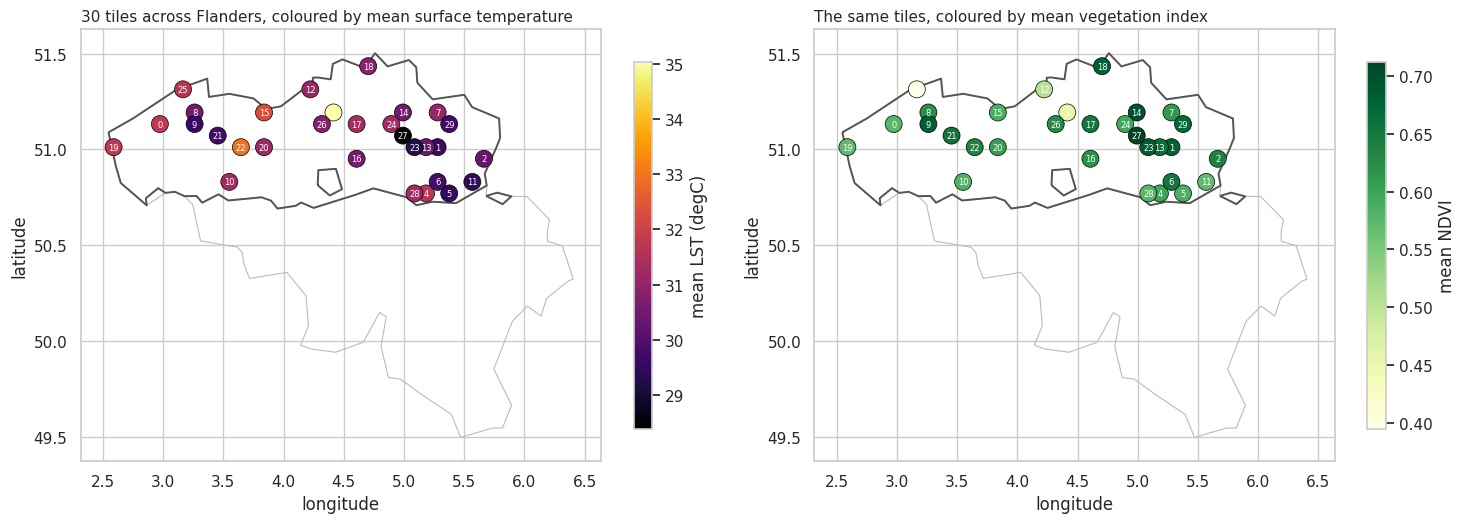

In [13]:
# 1/cos(mean latitude) keeps a degree of longitude visually proportional to a degree of latitude.
# Near 51N a longitude degree is about 70 km against 111 km for latitude, so without this the
# study area is stretched sideways by roughly a third.
geo_aspect = 1 / np.cos(np.radians(tiles.lat.mean()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

for ax, col, label, cmap in [(axes[0], "lst_mean", "mean LST (degC)", "inferno"),
                             (axes[1], "ndvi_mean", "mean NDVI", "YlGn")]:
    if belgium is not None:
        belgium.boundary.plot(ax=ax, color="#bbbbbb", linewidth=0.8, zorder=1)
    if flanders_outline is not None:
        flanders_outline.boundary.plot(ax=ax, color="#555555", linewidth=1.4, zorder=2)

    pts = ax.scatter(tiles.lon, tiles.lat, c=tiles[col], s=150, cmap=cmap,
                     edgecolor="black", linewidth=0.5, zorder=3)
    for _, t in tiles.iterrows():
        ax.annotate(int(t[GROUP_COLUMN]), (t.lon, t.lat), fontsize=6,
                    ha="center", va="center", color="white", zorder=4)

    fig.colorbar(pts, ax=ax, label=label, shrink=0.85)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect(geo_aspect, adjustable="datalim")
    ax.margins(0.06)

axes[0].set_title(f"{len(tiles)} tiles across Flanders, coloured by mean surface temperature",
                  loc="left", fontsize=11)
axes[1].set_title("The same tiles, coloured by mean vegetation index", loc="left", fontsize=11)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "tile_map.png", dpi=150, bbox_inches="tight")
plt.show()

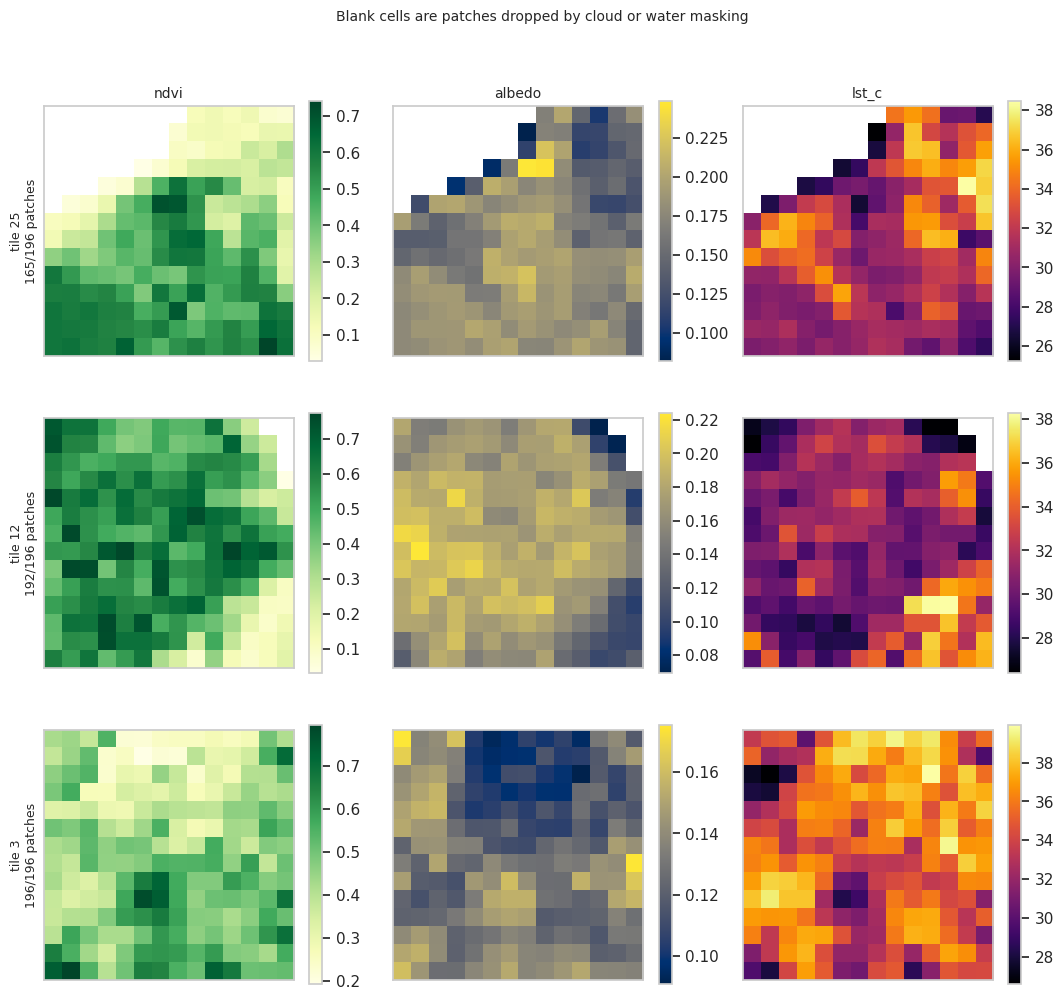

In [14]:
def tile_grid(tile_id, column):
    """Reshape one tile's patch values back into its 14x14 spatial layout.

    Dropped patches leave gaps, so this pivots on the stored row and column indices rather than
    reshaping in order, and reindexes to the full grid so a missing patch shows as blank rather
    than shifting every value after it.
    """
    sub = patches[patches[GROUP_COLUMN] == tile_id]
    grid = sub.pivot(index="patch_row", columns="patch_col", values=column)
    return grid.reindex(index=range(N_PATCH_SIDE), columns=range(N_PATCH_SIDE)).values


# The two least complete tiles alongside a complete one, so the gaps are visible next to what a
# full tile looks like.
show_tiles = list(tiles.nsmallest(2, "n_patches")[GROUP_COLUMN]) + \
             list(tiles.nlargest(1, "lst_mean")[GROUP_COLUMN])

fig, axes = plt.subplots(len(show_tiles), 3, figsize=(11, 3.4 * len(show_tiles)))

for row, tile_id in enumerate(show_tiles):
    n_kept = int(tiles.loc[tiles[GROUP_COLUMN] == tile_id, "n_patches"].iloc[0])
    for col, (name, cmap) in enumerate([("ndvi", "YlGn"), ("albedo", "cividis"),
                                        ("lst_c", "inferno")]):
        ax = axes[row, col]
        im = ax.imshow(tile_grid(tile_id, name), cmap=cmap)
        fig.colorbar(im, ax=ax, shrink=0.8)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(name, fontsize=10)
    axes[row, 0].set_ylabel(f"tile {tile_id}\n{n_kept}/{PATCHES_PER_TILE} patches", fontsize=9)

fig.suptitle("Blank cells are patches dropped by cloud or water masking",
             fontsize=10, y=1.005)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "tile_examples.png", dpi=150, bbox_inches="tight")
plt.show()

anchor tile 26, nearest neighbours [3, 17] at [9.5, 20.1] km


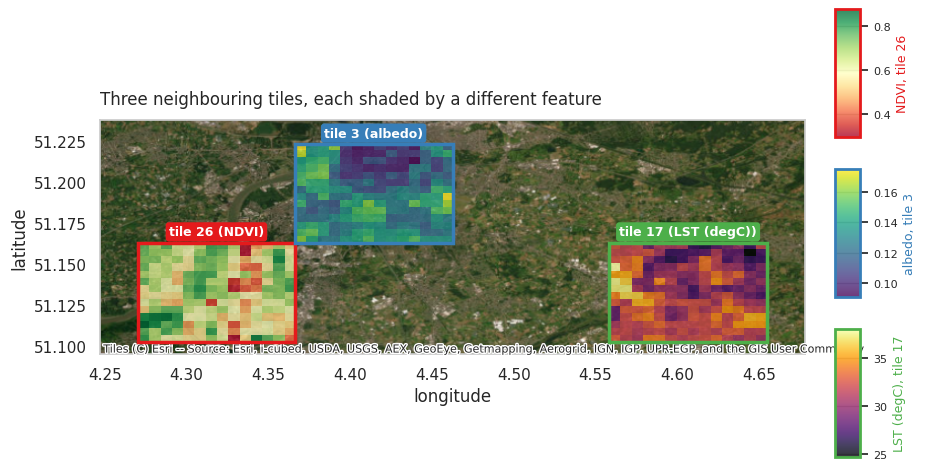

In [15]:
# Three tiles that are genuinely close together, not three drawn at random. The anchor is the
# tile nearest the centroid of all tile centres, so the choice follows from the sample rather
# than from a hand-picked index, and its two nearest neighbours join it. Each is shaded by a
# different variable over the same satellite imagery, which is the clearest way to see that
# adjacent tiles share a landscape before Section 4 relies on that being true.
anchor_id = int(tiles.iloc[
    np.argmin(haversine_km(tiles.lat.values, tiles.lon.values,
                           tiles.lat.mean(), tiles.lon.mean()))
][GROUP_COLUMN])

anchor = tiles[tiles[GROUP_COLUMN] == anchor_id].iloc[0]
neighbours = tiles[tiles[GROUP_COLUMN] != anchor_id].copy()
neighbours["km_to_anchor"] = haversine_km(neighbours.lat.values, neighbours.lon.values,
                                          anchor.lat, anchor.lon)
trio = [anchor_id] + [int(t) for t in neighbours.nsmallest(2, "km_to_anchor")[GROUP_COLUMN]]

print(f"anchor tile {anchor_id}, nearest neighbours {trio[1:]} at "
      f"{neighbours.nsmallest(2, 'km_to_anchor').km_to_anchor.round(1).tolist()} km")

layers = [("ndvi", "RdYlGn", "NDVI"), ("albedo", "viridis", "albedo"), (TARGET, "inferno", "LST (degC)")]
outline_colors = ["#e41a1c", "#377eb8", "#4daf4a"]

fig, ax = plt.subplots(figsize=(10, 8))
lons, lats, drawn = [], [], []

for i, (tile_id, (feature, cmap, label)) in enumerate(zip(trio, layers)):
    row = tiles[tiles[GROUP_COLUMN] == tile_id].iloc[0]
    half_lat = (TILE_SIZE_M / 2) / 111000
    half_lon = (TILE_SIZE_M / 2) / (111000 * np.cos(np.radians(row.lat)))
    extent = [row.lon - half_lon, row.lon + half_lon, row.lat - half_lat, row.lat + half_lat]
    lons += extent[:2]
    lats += extent[2:]

    im = ax.imshow(np.ma.masked_invalid(tile_grid(tile_id, feature)), cmap=cmap,
                   origin="upper", extent=extent, alpha=0.78, zorder=3)
    drawn.append((im, label, outline_colors[i], tile_id))

    ax.add_patch(mpatches.Rectangle((extent[0], extent[2]), 2 * half_lon, 2 * half_lat,
                                    linewidth=2.5, edgecolor=outline_colors[i],
                                    facecolor="none", zorder=4))
    ax.text(row.lon, extent[3] + half_lat * 0.09, f"tile {tile_id} ({label})",
            color="white", fontsize=9, fontweight="bold", ha="center", va="bottom", zorder=5,
            bbox=dict(boxstyle="round,pad=0.25", facecolor=outline_colors[i], edgecolor="none"))

pad_x = (max(lons) - min(lons)) * 0.06
pad_y = (max(lats) - min(lats)) * 0.06
ax.set_xlim(min(lons) - pad_x, max(lons) + pad_x)
ax.set_ylim(min(lats) - pad_y, max(lats) + pad_y * 2)  # headroom for the labels

if DRAW_BASEMAPS:
    try:
        cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldImagery, zorder=1)
    except Exception as e:
        print(f"satellite basemap unavailable ({type(e).__name__}); tiles drawn on a plain axis")

for i, (im, label, color, tile_id) in enumerate(drawn):
    cax = fig.add_axes([0.86, 0.62 - i * 0.20, 0.025, 0.16])
    bar = fig.colorbar(im, cax=cax)
    bar.set_label(f"{label}, tile {tile_id}", fontsize=9, color=color)
    bar.ax.tick_params(labelsize=8)
    bar.outline.set_edgecolor(color)
    bar.outline.set_linewidth(2)

ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Three neighbouring tiles, each shaded by a different feature",
             loc="left", fontsize=12, pad=12)

plt.subplots_adjust(right=0.83)
fig.savefig(FIGURE_DIR / "adjacent_tiles.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# How much of the variation in temperature is between tiles rather than within them. This is the
# quantitative form of the argument in Section 1, and it is reported whichever way it comes out.
grand_mean = patches[TARGET].mean()
group_sizes = patches.groupby(GROUP_COLUMN)[TARGET].size()
group_means = patches.groupby(GROUP_COLUMN)[TARGET].mean()

ss_total = ((patches[TARGET] - grand_mean) ** 2).sum()
ss_between = (group_sizes * (group_means - grand_mean) ** 2).sum()
between_share = ss_between / ss_total

within_sd = patches.groupby(GROUP_COLUMN)[TARGET].std()

print(f"between-tile share of total {TARGET} variance: {between_share:.1%}")
print(f"tile mean temperature spans {group_means.max() - group_means.min():.1f} degC")
print(f"total spread: {patches[TARGET].std():.2f} degC")
print(f"typical within-tile spread: {within_sd.median():.2f} degC "
      f"(range {within_sd.min():.2f} to {within_sd.max():.2f})")

between-tile share of total lst_c variance: 19.9%
tile mean temperature spans 6.7 degC
total spread: 2.84 degC
typical within-tile spread: 2.49 degC (range 1.09 to 3.91)


Most of the variation is within tiles, not between them. Tile identity accounts for about a
fifth of the total variance, and the typical spread inside a single tile is nearly as wide as
the spread across the whole dataset. Whatever the model has to learn, it is mostly learning to
tell one part of a tile from another rather than one tile from the next.

That is a weaker case for spatial cross-validation than a strongly clustered target would give,
and it is worth stating plainly. A random fold would let the model recover a tile's mean
temperature from the training half and apply it to the test half, and that mean carries about
20% of the target. Real, but not the whole story.

The stronger reason is the one visible in the tile separations above. The closest pair of tile
centres is one tile width apart, so two tiles in this sample sit edge to edge. Patches on either
side of that shared edge are a few hundred metres apart and share a weather composite, and no
grouping on tile identity can separate them. `GroupKFold` removes the largest and most obvious
form of leakage without producing genuinely independent test sets, which is why Section 10 goes
to a different region rather than treating a cross-validated score as the last word.

## 4. Cross-validation

Splits are generated once here, saved, and reused by every modelling section that follows. No
later section builds its own folds, so any two results in this notebook are always computed on
the same partition and remain directly comparable.

`GroupKFold` is deterministic given the same grouping and number of splits, so these folds
reproduce exactly without a seed.

In [17]:
def build_folds():
    splitter = GroupKFold(n_splits=N_SPLITS)
    fold_of_row = np.empty(len(patches), dtype=int)
    for fold_idx, (_, test_rows) in enumerate(splitter.split(patches, groups=patches[GROUP_COLUMN])):
        fold_of_row[test_rows] = fold_idx

    assignment = pd.DataFrame({GROUP_COLUMN: patches[GROUP_COLUMN], "fold": fold_of_row})
    per_tile_folds = assignment.groupby(GROUP_COLUMN)["fold"].nunique()
    if (per_tile_folds > 1).any():
        raise RuntimeError("a tile was assigned to more than one fold; grouping failed")

    return {"folds": assignment.drop_duplicates().sort_values(GROUP_COLUMN).reset_index(drop=True)}


fold_assignment = cached({"folds": RESULT_DIR / "folds.csv"}, build_folds)["folds"]
fold_of_tile = dict(zip(fold_assignment[GROUP_COLUMN], fold_assignment["fold"]))

patches["fold"] = patches[GROUP_COLUMN].map(fold_of_tile)
tiles["fold"] = tiles[GROUP_COLUMN].map(fold_of_tile)

if patches["fold"].isna().any():
    raise RuntimeError("some patches have no fold assignment")

cached: folds.csv


In [18]:
fold_table = (patches.groupby("fold")
              .agg(test_tiles=(GROUP_COLUMN, "nunique"),
                   test_patches=(TARGET, "size"),
                   lst_mean=(TARGET, "mean"),
                   lst_sd=(TARGET, "std"))
              .reset_index())
fold_table["train_tiles"] = tiles[GROUP_COLUMN].nunique() - fold_table["test_tiles"]
fold_table["train_patches"] = len(patches) - fold_table["test_patches"]

# Folds hold out whole tiles, so they will not be exactly equal in size. What matters is that no
# fold is so small or so unusual in its temperature distribution that its metrics are measuring
# the fold rather than the model.
print(fold_table[["fold", "train_tiles", "test_tiles", "train_patches",
                  "test_patches", "lst_mean", "lst_sd"]].to_string(index=False))
print()
print(f"test-fold mean temperature ranges {fold_table.lst_mean.min():.1f} to "
      f"{fold_table.lst_mean.max():.1f} degC across folds")

 fold  train_tiles  test_tiles  train_patches  test_patches  lst_mean   lst_sd
    0           24           6           4669          1176 30.516516 2.740257
    1           24           6           4669          1176 31.195632 2.375774
    2           24           6           4669          1176 30.214877 3.170010
    3           24           6           4673          1172 30.568703 2.756922
    4           24           6           4700          1145 31.671200 2.878989

test-fold mean temperature ranges 30.2 to 31.7 degC across folds


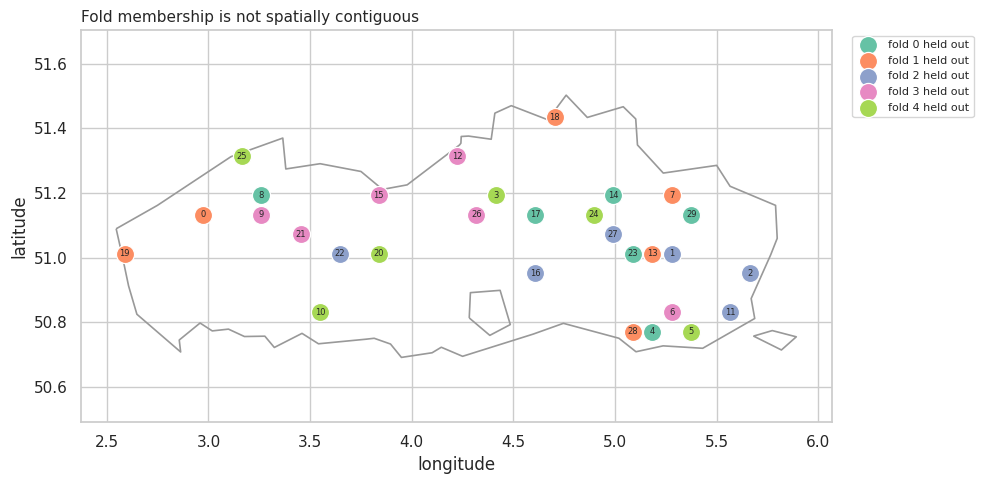

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

if flanders_outline is not None:
    flanders_outline.boundary.plot(ax=ax, color="#999999", linewidth=1.2, zorder=1)

palette = sns.color_palette("Set2", N_SPLITS)
for fold_idx in range(N_SPLITS):
    sel = tiles[tiles.fold == fold_idx]
    ax.scatter(sel.lon, sel.lat, s=170, color=palette[fold_idx], edgecolor="white",
               linewidth=0.9, zorder=3, label=f"fold {fold_idx} held out")
    for _, t in sel.iterrows():
        ax.annotate(int(t[GROUP_COLUMN]), (t.lon, t.lat), fontsize=6,
                    ha="center", va="center", zorder=4)

ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_aspect(geo_aspect, adjustable="datalim")
ax.margins(0.08)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title("Fold membership is not spatially contiguous", loc="left", fontsize=11)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "fold_map.png", dpi=150, bbox_inches="tight")
plt.show()

`GroupKFold` balances fold sizes rather than grouping tiles by location, so each fold draws
tiles from across the study area instead of carving out one contiguous block. Every fold's test
set stays representative of Flanders as a whole, and mean test-fold temperature varies by only
about 1.5 degC across the five folds, so no fold is scoring a materially different problem from
the others.

What this does not do is make test tiles independent of training tiles. Tile centres here are as
close as one tile width, and a held-out tile with a training neighbour sharing its edge is still
being predicted partly from its own surroundings. Holding out whole tiles is the strongest
control available within a single region; establishing that anything transfers beyond it
requires leaving the region entirely, which Section 10 does.

## 5. Random Forest benchmark

The three conditions from Section 1, each fitted on the same five folds. Out-of-fold predictions
are written once here and every later section reads them, so nothing downstream retrains a model
or reproduces a split.

In [20]:
CONDITIONS = ["traditional", "gfm_full", "combined"]


def run_benchmark():
    y = patches[TARGET].values
    fold = patches["fold"].values
    X_traditional = patches[TRADITIONAL_FEATURES].values

    oof = {c: np.full(len(y), np.nan) for c in CONDITIONS}
    records = []

    for fold_idx in range(N_SPLITS):
        test = fold == fold_idx
        train = ~test

        # Standardising has no effect on a Random Forest, which only ever compares a feature to
        # a threshold and is unchanged by any monotone rescaling of that feature. It is done
        # anyway so that Section 6 fits PCA on exactly the matrix benchmarked here, where the
        # scaling genuinely does change the result. The scaler sees training rows only.
        scaler = StandardScaler().fit(embeddings[train])
        gfm_train, gfm_test = scaler.transform(embeddings[train]), scaler.transform(embeddings[test])

        matrices = {
            "traditional": (X_traditional[train], X_traditional[test]),
            "gfm_full": (gfm_train, gfm_test),
            "combined": (np.hstack([X_traditional[train], gfm_train]),
                         np.hstack([X_traditional[test], gfm_test])),
        }

        for name, (X_train, X_test) in matrices.items():
            model = RandomForestRegressor(**RF_PARAMS).fit(X_train, y[train])
            pred = model.predict(X_test)
            oof[name][test] = pred
            records.append({"fold": fold_idx, "condition": name,
                            "n_test": int(test.sum()),
                            "r2": r2_score(y[test], pred),
                            "rmse": float(np.sqrt(mean_squared_error(y[test], pred))),
                            "mae": mean_absolute_error(y[test], pred)})
        print(f"  fold {fold_idx}: " + "  ".join(
            f"{r['condition']} R2={r['r2']:.3f}" for r in records[-len(CONDITIONS):]))

    predictions = pd.DataFrame({GROUP_COLUMN: patches[GROUP_COLUMN], "fold": fold,
                                "y_true": y, **{f"pred_{c}": oof[c] for c in CONDITIONS}})

    return {"metrics": pd.DataFrame(records), "predictions": predictions}


benchmark = cached({"metrics": RESULT_DIR / "benchmark_metrics.csv",
                    "predictions": RESULT_DIR / "oof_predictions.csv"},
                   run_benchmark)

fold_metrics, oof_predictions = benchmark["metrics"], benchmark["predictions"]

if oof_predictions[[f"pred_{c}" for c in CONDITIONS]].isna().any().any():
    raise RuntimeError("some rows have no out-of-fold prediction; a fold did not cover them")

cached: benchmark_metrics.csv, oof_predictions.csv


In [21]:
summary = (fold_metrics.groupby("condition")
           .agg(r2_mean=("r2", "mean"), r2_sd=("r2", "std"),
                rmse_mean=("rmse", "mean"), rmse_sd=("rmse", "std"),
                mae_mean=("mae", "mean"))
           .reindex(CONDITIONS)
           .reset_index())

print(summary.to_string(index=False))

wide = fold_metrics.pivot(index="fold", columns="condition", values="r2")
print()
for challenger in ("gfm_full", "combined"):
    delta = wide[challenger] - wide["traditional"]
    print(f"{challenger} vs traditional: wins {int((delta > 0).sum())}/{N_SPLITS} folds, "
          f"mean delta R2 {delta.mean():+.3f}, worst fold {delta.min():+.3f}")

delta_combined = wide["combined"] - wide["gfm_full"]
print(f"combined vs gfm_full: wins {int((delta_combined > 0).sum())}/{N_SPLITS} folds, "
      f"mean delta R2 {delta_combined.mean():+.3f}")

# No significance test is reported for these differences. With five folds there are five paired
# observations, and they are not independent of one another: every pair of training sets built
# by K-fold overlaps in most of its rows, so the spread across folds understates the true
# variability and any t-test built on it returns a p-value that is too small. Counting how many
# folds each condition wins, and by how much in the worst one, says what the data supports.

  condition  r2_mean    r2_sd  rmse_mean  rmse_sd  mae_mean
traditional 0.634795 0.064212   1.670987 0.159990  1.269689
   gfm_full 0.661835 0.034013   1.613576 0.142978  1.243963
   combined 0.676478 0.039252   1.576069 0.128736  1.208706

gfm_full vs traditional: wins 4/5 folds, mean delta R2 +0.027, worst fold -0.018
combined vs traditional: wins 5/5 folds, mean delta R2 +0.042, worst fold +0.006
combined vs gfm_full: wins 5/5 folds, mean delta R2 +0.015


In [22]:
per_fold = fold_metrics.pivot(index="fold", columns="condition", values="r2")[CONDITIONS]
per_fold["combined - traditional"] = per_fold["combined"] - per_fold["traditional"]

print(per_fold.round(3).to_string())
print()

worst = per_fold["traditional"].idxmin()
# Where the gain sits matters more than its average. If the extra features only helped on folds
# the baseline already handled, they would be adding accuracy where accuracy was cheap.
print(f"traditional is weakest on fold {worst} (R2={per_fold.loc[worst, 'traditional']:.3f}), "
      f"where combined reaches {per_fold.loc[worst, 'combined']:.3f}, "
      f"a gain of {per_fold.loc[worst, 'combined - traditional']:+.3f}")
print(f"that is {per_fold.loc[worst, 'combined - traditional'] / per_fold['combined - traditional'].mean():.1f}x "
      f"the mean gain of {per_fold['combined - traditional'].mean():+.3f}")
print(f"spread across folds: traditional sd {per_fold['traditional'].std():.3f}, "
      f"combined sd {per_fold['combined'].std():.3f}")

condition  traditional  gfm_full  combined  combined - traditional
fold                                                              
0                0.668     0.690     0.699                   0.032
1                0.624     0.644     0.653                   0.029
2                0.708     0.690     0.714                   0.006
3                0.535     0.611     0.619                   0.084
4                0.640     0.675     0.697                   0.057

traditional is weakest on fold 3 (R2=0.535), where combined reaches 0.619, a gain of +0.084
that is 2.0x the mean gain of +0.042
spread across folds: traditional sd 0.064, combined sd 0.039


The average gain is small. Adding a 1024-dimensional embedding to three spectral indices moves
mean R² by about 0.04 and RMSE by roughly a tenth of a degree, which on its own would be a thin
result for a 300-million-parameter backbone.

The change in consistency is larger than the change in level. Fold-to-fold variability falls by
close to half, and the gain concentrates on the fold where the spectral indices do worst rather
than spreading evenly. On that fold the baseline drops well below its own average while the
combined model barely moves.

That pattern is worth more than the mean, because a model is only as useful as its behaviour on
the landscape it handles least well. It also frames what Section 10 is testing: if the
embedding's contribution is to hold performance up where spectral indices become unreliable,
then a region the model has never seen is exactly where that contribution should show, or fail
to.

Both conditions that include the embedding beat the baseline on almost every fold, but the
margins are small enough that the direction of the result is better supported than its size.

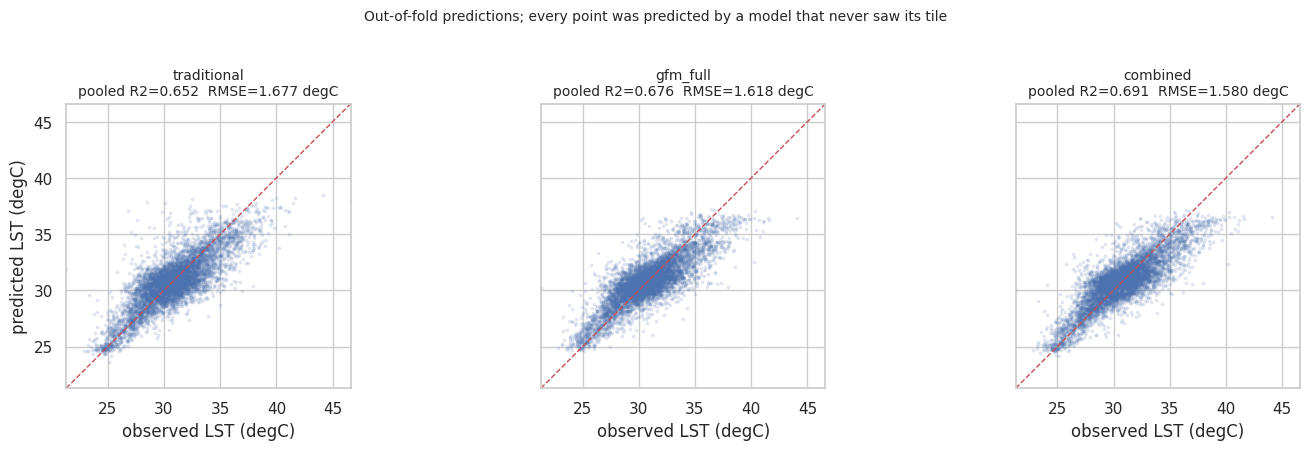

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharey=True)

lo = min(oof_predictions.y_true.min(), oof_predictions[[f"pred_{c}" for c in CONDITIONS]].min().min())
hi = max(oof_predictions.y_true.max(), oof_predictions[[f"pred_{c}" for c in CONDITIONS]].max().max())

for ax, condition in zip(axes, CONDITIONS):
    pred = oof_predictions[f"pred_{condition}"]
    ax.scatter(oof_predictions.y_true, pred, s=3, alpha=0.12, color="#4C72B0")
    ax.plot([lo, hi], [lo, hi], color="#C44E52", linewidth=1, linestyle="--")
    r2 = r2_score(oof_predictions.y_true, pred)
    rmse = np.sqrt(mean_squared_error(oof_predictions.y_true, pred))
    ax.set_title(f"{condition}\npooled R2={r2:.3f}  RMSE={rmse:.3f} degC", fontsize=10)
    ax.set_xlabel("observed LST (degC)")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")

axes[0].set_ylabel("predicted LST (degC)")
fig.suptitle("Out-of-fold predictions; every point was predicted by a model that never saw its tile",
             fontsize=10, y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "benchmark_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Does compressing the embedding help?

Question 4 from Section 1. A 1024-dimensional feature vector fitted on roughly 4,700 training
rows is a wide problem, and compressing it is the obvious response. Whether compression actually
helps is a question rather than an assumption, because principal components are ordered by how
much variance they explain and nothing guarantees that the directions carrying the most variance
are the directions carrying the most information about temperature.

Every PCA here is fitted inside a training fold and applied to that fold's held-out tiles. A PCA
fitted across the whole dataset would have seen the test rows, and the resulting scores would
carry information no deployed model could have.

In [24]:
PCA_DIMS = [d for d in PCA_SWEEP if d != GFM_DIM]


def run_pca_ablation():
    y = patches[TARGET].values
    fold = patches["fold"].values
    X_traditional = patches[TRADITIONAL_FEATURES].values

    records = []
    for fold_idx in range(N_SPLITS):
        test = fold == fold_idx
        train = ~test

        scaler = StandardScaler().fit(embeddings[train])
        gfm_train, gfm_test = scaler.transform(embeddings[train]), scaler.transform(embeddings[test])

        # Principal components are nested, so the first k columns of a solution with max(PCA_DIMS)
        # components are exactly the k-component solution. One fit per fold therefore serves the
        # whole sweep, instead of refitting for every dimensionality.
        pca = PCA(n_components=max(PCA_DIMS), random_state=RANDOM_SEED).fit(gfm_train)
        scores_train, scores_test = pca.transform(gfm_train), pca.transform(gfm_test)

        for n_components in PCA_DIMS:
            reduced_train = scores_train[:, :n_components]
            reduced_test = scores_test[:, :n_components]
            variants = {
                "gfm_full": (reduced_train, reduced_test),
                "combined": (np.hstack([X_traditional[train], reduced_train]),
                             np.hstack([X_traditional[test], reduced_test])),
            }
            for condition, (X_train, X_test) in variants.items():
                model = RandomForestRegressor(**RF_PARAMS).fit(X_train, y[train])
                records.append({
                    "fold": fold_idx, "condition": condition, "n_components": n_components,
                    "r2": r2_score(y[test], model.predict(X_test)),
                    "explained_variance": float(pca.explained_variance_ratio_[:n_components].sum()),
                })
        print(f"  fold {fold_idx} done")

    return {"ablation": pd.DataFrame(records)}


ablation = cached({"ablation": RESULT_DIR / "pca_ablation.csv"}, run_pca_ablation)["ablation"]

cached: pca_ablation.csv


In [25]:
# The uncompressed result already exists from Section 5; recomputing it here would fit the same
# model twice and risk the two copies disagreeing. It is appended as the sweep's right-hand end.
full_dim = (fold_metrics[fold_metrics.condition.isin(["gfm_full", "combined"])]
            [["fold", "condition", "r2"]].copy())
full_dim["n_components"] = GFM_DIM
full_dim["explained_variance"] = 1.0

sweep = pd.concat([ablation, full_dim], ignore_index=True)

curve = (sweep.groupby(["condition", "n_components"])
         .agg(r2_mean=("r2", "mean"), r2_sd=("r2", "std"),
              explained=("explained_variance", "mean"))
         .reset_index())

print(curve.pivot(index="n_components", columns="condition", values="r2_mean").to_string())
print()
for condition in ("gfm_full", "combined"):
    sub = curve[curve.condition == condition].set_index("n_components")["r2_mean"]
    best = sub.idxmax()
    if best == GFM_DIM:
        print(f"{condition}: best R2 {sub.max():.3f} at the full {GFM_DIM} dimensions; "
              f"no compression tested improved on it "
              f"(best compressed: {sub.drop(GFM_DIM).max():.3f} at "
              f"{sub.drop(GFM_DIM).idxmax()} components)")
    else:
        print(f"{condition}: best R2 {sub.max():.3f} at {best} components, against "
              f"{sub[GFM_DIM]:.3f} uncompressed, a gain of {sub.max() - sub[GFM_DIM]:+.3f}")

condition     combined  gfm_full
n_components                    
5             0.663108  0.433588
15            0.671968  0.497754
30            0.674152  0.539130
50            0.673001  0.533978
100           0.669442  0.524637
200           0.664799  0.512902
1024          0.676478  0.661835

gfm_full: best R2 0.662 at the full 1024 dimensions; no compression tested improved on it (best compressed: 0.539 at 30 components)
combined: best R2 0.676 at the full 1024 dimensions; no compression tested improved on it (best compressed: 0.674 at 30 components)


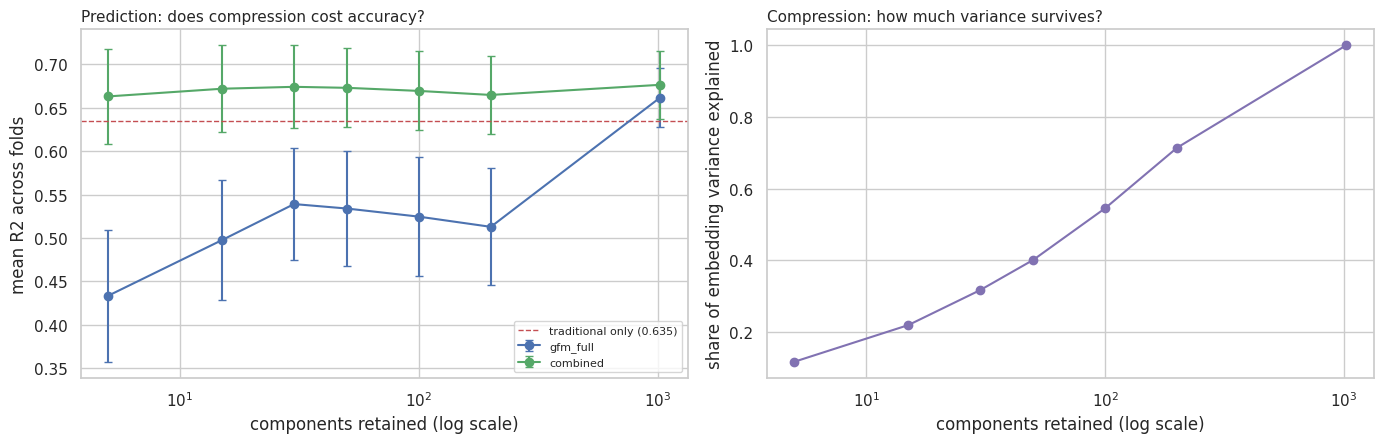

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

for condition, color in [("gfm_full", "#4C72B0"), ("combined", "#55A868")]:
    sub = curve[curve.condition == condition].sort_values("n_components")
    axes[0].errorbar(sub.n_components, sub.r2_mean, yerr=sub.r2_sd, marker="o",
                     capsize=3, color=color, label=condition)

traditional_r2 = summary.loc[summary.condition == "traditional", "r2_mean"].iloc[0]
axes[0].axhline(traditional_r2, color="#C44E52", linestyle="--", linewidth=1,
                label=f"traditional only ({traditional_r2:.3f})")
axes[0].set_xscale("log")
axes[0].set_xlabel("components retained (log scale)")
axes[0].set_ylabel("mean R2 across folds")
axes[0].set_title("Prediction: does compression cost accuracy?", loc="left", fontsize=11)
axes[0].legend(fontsize=8)

variance_curve = curve[curve.condition == "gfm_full"].sort_values("n_components")
axes[1].plot(variance_curve.n_components, variance_curve.explained, marker="o", color="#8172B2")
axes[1].set_xscale("log")
axes[1].set_xlabel("components retained (log scale)")
axes[1].set_ylabel("share of embedding variance explained")
axes[1].set_title("Compression: how much variance survives?", loc="left", fontsize=11)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "pca_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

The two panels answer different questions and should not be read as one. The right-hand panel
reports how much of the embedding's own variance a given number of components retains; the
left-hand panel reports how well a model built on those components predicts temperature.

The embedding alone loses a large share of its predictive value under compression, and does not
recover it by keeping more components. Two hundred components perform no better than thirty,
and both fall well short of the uncompressed representation. Retained variance is not the
constraint here, because the components being discarded are far down the ordering.

The likely reason is that a Random Forest is not invariant to rotation. It splits one feature at
a time against a threshold, so it benefits when the informative signal is concentrated in
individual coordinates. PCA rotates the space to align with directions of maximum variance,
which spreads whatever predicts temperature across many components at once and leaves every
axis-aligned split less effective than it was in the original basis. Compression is not the only
thing PCA does to this representation.

The combined condition is nearly flat across the whole sweep, including at five components. Once
NDVI, NDBI and albedo are present they carry most of what a compressed embedding would have
contributed, so the compression cost is largely hidden. Reading only that curve would suggest
the embedding compresses cheaply, which the other curve shows it does not.

## 7. Where does the model work, and where does it fail?

Fold-level averages hide the shape of the error. Every patch in `oof_predictions` was predicted
by a model that never saw its tile, so tile-level accuracy can be read directly off those
predictions without fitting anything new.

Accuracy is reported here as RMSE rather than R². R² measures error against the variance of
whatever it is computed over, and within-tile spread in this dataset ranges from about 1.1 to
3.9 degC. The same absolute error therefore produces very different R² values depending on which
tile it falls in, which makes per-tile R² a poor basis for ranking tiles against each other.

In [27]:
BEST_CONDITION = "combined"  # Section 5: highest mean R2, lowest RMSE, wins every fold

oof = oof_predictions.copy()
for condition in CONDITIONS:
    oof[f"residual_{condition}"] = oof[f"pred_{condition}"] - oof["y_true"]

tile_errors = (oof.groupby(GROUP_COLUMN)
               .apply(lambda g: pd.Series({
                   "fold": g["fold"].iloc[0],
                   "n_patches": len(g),
                   "observed_sd": g["y_true"].std(),
                   "rmse": np.sqrt(mean_squared_error(g["y_true"], g[f"pred_{BEST_CONDITION}"])),
                   "bias": g[f"residual_{BEST_CONDITION}"].mean(),
                   "rmse_traditional": np.sqrt(mean_squared_error(g["y_true"], g["pred_traditional"])),
               }), include_groups=False)
               .reset_index())

tile_errors = tile_errors.merge(
    tiles[[GROUP_COLUMN, "lat", "lon", "lst_mean", "ndvi_mean", "ndbi_mean", "albedo_mean"]],
    on=GROUP_COLUMN)
tile_errors["rmse_gain"] = tile_errors["rmse_traditional"] - tile_errors["rmse"]

pooled_rmse = np.sqrt(mean_squared_error(oof["y_true"], oof[f"pred_{BEST_CONDITION}"]))
print(f"pooled out-of-fold RMSE: {pooled_rmse:.3f} degC")
print(f"per-tile RMSE: {tile_errors.rmse.min():.2f} to {tile_errors.rmse.max():.2f} degC, "
      f"median {tile_errors.rmse.median():.2f}")
print(f"per-tile bias: {tile_errors.bias.min():+.2f} to {tile_errors.bias.max():+.2f} degC")
print()
print(tile_errors.nlargest(5, "rmse")[
    [GROUP_COLUMN, "fold", "n_patches", "observed_sd", "rmse", "bias", "rmse_gain"]
].round(2).to_string(index=False))

pooled out-of-fold RMSE: 1.580 degC
per-tile RMSE: 0.81 to 2.48 degC, median 1.44
per-tile bias: -2.06 to +1.79 degC

 tile_id  fold  n_patches  observed_sd  rmse  bias  rmse_gain
      22   2.0      196.0         2.28  2.48 -2.06      -0.01
       8   0.0      196.0         3.41  2.47  0.69       0.13
      11   2.0      196.0         1.68  2.13  1.79       0.03
       3   4.0      196.0         2.69  2.11 -1.58       0.00
      15   3.0      196.0         2.97  2.09 -0.85       0.14


In [28]:
# RMSE mixes two different failures. A tile can be wrong because predictions scatter around the
# right level, or because they cluster tightly around the wrong one. Separating them matters:
# scatter points at features that fail to resolve variation inside the tile, while a constant
# offset points at a tile-level property the model had no way to recover once that tile was
# held out. Section 3 measured how much of the target such properties carry.
tile_errors["scatter"] = np.sqrt((tile_errors.rmse ** 2 - tile_errors.bias ** 2).clip(lower=0))
tile_errors["bias_share"] = (tile_errors.bias ** 2) / (tile_errors.rmse ** 2)

print(tile_errors.nlargest(6, "rmse")[
    [GROUP_COLUMN, "rmse", "bias", "scatter", "bias_share", "observed_sd"]
].round(2).to_string(index=False))

print()
print(f"across all tiles, offset accounts for a median {tile_errors.bias_share.median():.0%} "
      f"of squared error, rising to {tile_errors.bias_share.max():.0%} at its worst")
print(f"correlation between tile RMSE and absolute bias: "
      f"{tile_errors.rmse.corr(tile_errors.bias.abs()):+.2f}")
print(f"correlation between tile RMSE and scatter: "
      f"{tile_errors.rmse.corr(tile_errors.scatter):+.2f}")

 tile_id  rmse  bias  scatter  bias_share  observed_sd
      22  2.48 -2.06     1.39        0.68         2.28
       8  2.47  0.69     2.37        0.08         3.41
      11  2.13  1.79     1.15        0.71         1.68
       3  2.11 -1.58     1.39        0.56         2.69
      15  2.09 -0.85     1.91        0.17         2.97
       9  1.95  0.43     1.90        0.05         3.01

across all tiles, offset accounts for a median 18% of squared error, rising to 71% at its worst
correlation between tile RMSE and absolute bias: +0.65
correlation between tile RMSE and scatter: +0.73


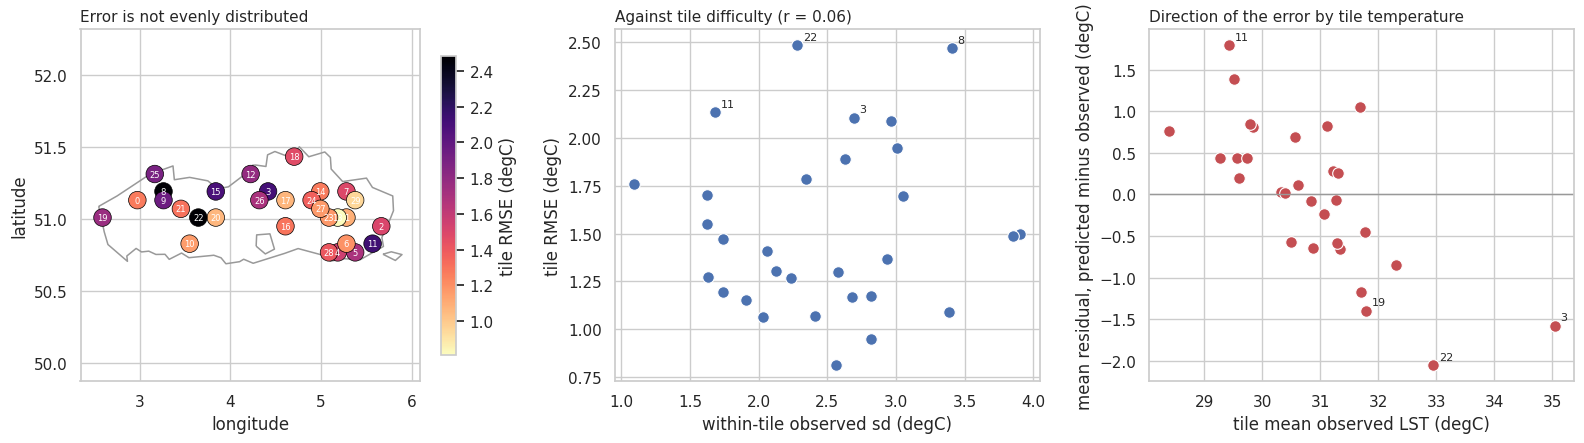

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

if flanders_outline is not None:
    flanders_outline.boundary.plot(ax=axes[0], color="#999999", linewidth=1.1, zorder=1)
pts = axes[0].scatter(tile_errors.lon, tile_errors.lat, c=tile_errors.rmse, s=160,
                      cmap="magma_r", edgecolor="black", linewidth=0.5, zorder=3)
for _, t in tile_errors.iterrows():
    axes[0].annotate(int(t[GROUP_COLUMN]), (t.lon, t.lat), fontsize=6,
                     ha="center", va="center", color="white", zorder=4)
fig.colorbar(pts, ax=axes[0], label="tile RMSE (degC)", shrink=0.85)
axes[0].set_aspect(geo_aspect, adjustable="datalim")
axes[0].margins(0.06)
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")
axes[0].set_title("Error is not evenly distributed", loc="left", fontsize=11)

# If tile RMSE simply tracked how variable a tile is, the model would be failing on hard tiles
# rather than on particular ones, and there would be nothing further to explain.
axes[1].scatter(tile_errors.observed_sd, tile_errors.rmse, s=70, color="#4C72B0",
                edgecolor="white", linewidth=0.8)
for _, t in tile_errors.nlargest(4, "rmse").iterrows():
    axes[1].annotate(int(t[GROUP_COLUMN]), (t.observed_sd, t.rmse), fontsize=8,
                     xytext=(4, 4), textcoords="offset points")
corr = tile_errors.observed_sd.corr(tile_errors.rmse)
axes[1].set_xlabel("within-tile observed sd (degC)")
axes[1].set_ylabel("tile RMSE (degC)")
axes[1].set_title(f"Against tile difficulty (r = {corr:.2f})", loc="left", fontsize=11)

axes[2].axhline(0, color="#999999", linewidth=1)
axes[2].scatter(tile_errors.lst_mean, tile_errors.bias, s=70, color="#C44E52",
                edgecolor="white", linewidth=0.8)
for _, t in tile_errors.reindex(tile_errors.bias.abs().nlargest(4).index).iterrows():
    axes[2].annotate(int(t[GROUP_COLUMN]), (t.lst_mean, t.bias), fontsize=8,
                     xytext=(4, 4), textcoords="offset points")
axes[2].set_xlabel("tile mean observed LST (degC)")
axes[2].set_ylabel("mean residual, predicted minus observed (degC)")
axes[2].set_title("Direction of the error by tile temperature", loc="left", fontsize=11)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "tile_errors.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
# A Random Forest predicts by averaging the training values that reach a leaf, so its output is
# pulled toward the middle of whatever those leaves contain. Extremes are therefore predicted too
# conservatively even when they sit well inside the training range, which is a property of the
# learner rather than a shortfall in the features. Establishing that it is present, and how
# large it is, keeps it from being mistaken for a feature failure in the next section.
bins = pd.qcut(oof["y_true"], 10)
by_temperature = oof.groupby(bins, observed=True).agg(
    observed=("y_true", "mean"),
    residual=(f"residual_{BEST_CONDITION}", "mean"),
    n=("y_true", "size")).reset_index(drop=True)

print(by_temperature.round(3).to_string(index=False))
print()
print(f"coldest decile: mean residual {by_temperature.residual.iloc[0]:+.2f} degC")
print(f"hottest decile: mean residual {by_temperature.residual.iloc[-1]:+.2f} degC")
print(f"training range available to any fold: {oof.y_true.min():.2f} to {oof.y_true.max():.2f} degC, "
      f"so the hottest decile at {by_temperature.observed.iloc[-1]:.1f} degC is "
      f"well inside it")

 observed  residual   n
   25.972     0.929 585
   27.953     1.172 584
   28.970     0.955 585
   29.773     0.681 584
   30.447     0.349 585
   31.087    -0.077 584
   31.724    -0.328 584
   32.518    -0.683 585
   33.661    -1.079 584
   36.186    -1.967 585

coldest decile: mean residual +0.93 degC
hottest decile: mean residual -1.97 degC
training range available to any fold: 21.30 to 46.61 degC, so the hottest decile at 36.2 degC is well inside it


Two separate things are going wrong, and they have different causes.

The first is a shrinkage toward the middle, visible as a clean gradient across the deciles: the
coldest patches are predicted about a degree too warm and the hottest about two degrees too
cool. Both ends sit comfortably inside the range the model was trained on, so this is not a
failure to extrapolate. It is what averaging inside leaves does to a skewed conditional
distribution, and it would appear with any features at all.

The second is tile-level. Some tiles carry a constant displacement, meaning the model reproduces
the pattern inside the tile while placing it at the wrong absolute level. That is the failure
Section 3 anticipated: about a fifth of the variance in this dataset is carried by which tile a
patch belongs to, and once a tile is held out entirely there is nothing in NDVI, NDBI, albedo or
the embedding that recovers its particular offset.

Displacement is not the general case, though. Across all thirty tiles it accounts for a median
of well under a quarter of squared error, and tile RMSE tracks scatter at least as closely as it
tracks bias. Both mechanisms are present and they affect different tiles, which the next section
separates before trying to explain either.

## 8. Testing an explanation for the worst tiles

Section 7 shows which tiles the model handles badly. This section asks why, by stating a
candidate explanation and testing it rather than describing the failures and stopping there.

A hypothesis that survives is worth reporting. One that does not is worth reporting too, and is
kept below rather than removed, because a rejected explanation narrows what the remaining ones
can be.

worst tiles by RMSE: [22, 8, 11]


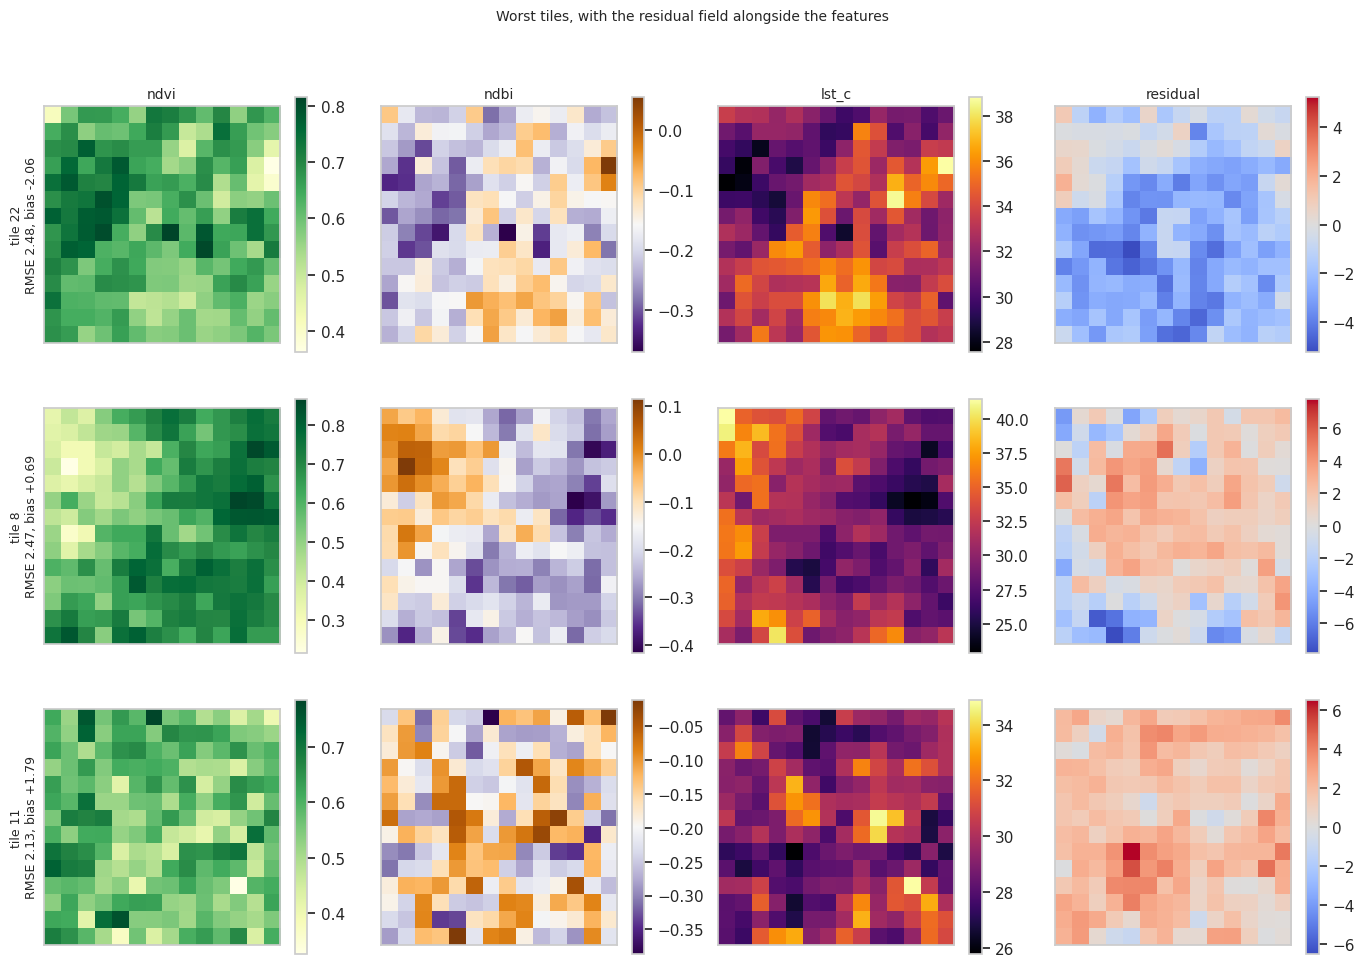

In [31]:
worst_tiles = tile_errors.nlargest(3, "rmse")[GROUP_COLUMN].astype(int).tolist()
print(f"worst tiles by RMSE: {worst_tiles}")

fig, axes = plt.subplots(len(worst_tiles), 4, figsize=(14, 3.3 * len(worst_tiles)))
residual_column = f"residual_{BEST_CONDITION}"

patches_with_residual = patches.copy()
patches_with_residual["residual"] = oof[residual_column].values

for row, tile_id in enumerate(worst_tiles):
    sub = patches_with_residual[patches_with_residual[GROUP_COLUMN] == tile_id]
    stats = tile_errors[tile_errors[GROUP_COLUMN] == tile_id].iloc[0]

    def grid(column):
        g = sub.pivot(index="patch_row", columns="patch_col", values=column)
        return g.reindex(index=range(N_PATCH_SIDE), columns=range(N_PATCH_SIDE)).values

    panels = [("ndvi", "YlGn", None), ("ndbi", "PuOr_r", None),
              (TARGET, "inferno", None), ("residual", "coolwarm", "symmetric")]

    for col, (column, cmap, scaling) in enumerate(panels):
        ax = axes[row, col]
        values = np.ma.masked_invalid(grid(column))
        limit = np.abs(values).max() if scaling == "symmetric" else None
        im = ax.imshow(values, cmap=cmap,
                       vmin=-limit if limit else None, vmax=limit if limit else None)
        fig.colorbar(im, ax=ax, shrink=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(column, fontsize=10)
    axes[row, 0].set_ylabel(f"tile {tile_id}\nRMSE {stats.rmse:.2f}, bias {stats.bias:+.2f}",
                            fontsize=9)

fig.suptitle("Worst tiles, with the residual field alongside the features",
             fontsize=10, y=1.005)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "worst_tiles.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# The worst tiles do not fail the same way. Splitting them by which term dominates asks whether
# the two groups differ in anything else, which is a stronger test than describing them one at a
# time. The 40% cut is descriptive rather than derived; it separates tiles where displacement is
# the larger term from those where it is not, and the groups below are far enough apart that a
# nearby threshold would sort them identically.
tile_errors["failure_mode"] = np.where(tile_errors.bias_share > 0.40, "offset", "scatter")

print(tile_errors.nlargest(6, "rmse")[
    [GROUP_COLUMN, "rmse", "bias", "scatter", "bias_share", "observed_sd", "failure_mode"]
].round(2).to_string(index=False))

print()
by_mode = tile_errors.groupby("failure_mode").agg(
    tiles=(GROUP_COLUMN, "size"),
    mean_rmse=("rmse", "mean"),
    mean_observed_sd=("observed_sd", "mean"),
    mean_ndvi=("ndvi_mean", "mean"),
    mean_gain=("rmse_gain", "mean"))
print(by_mode.round(3).to_string())

print()
print("Offset tiles are ones the model places at the wrong level while resolving their internal "
      "pattern; scatter tiles are ones whose internal variation it fails to resolve at all. "
      "The clearest thing separating them is how much temperature varies inside the tile.")

 tile_id  rmse  bias  scatter  bias_share  observed_sd failure_mode
      22  2.48 -2.06     1.39        0.68         2.28       offset
       8  2.47  0.69     2.37        0.08         3.41      scatter
      11  2.13  1.79     1.15        0.71         1.68       offset
       3  2.11 -1.58     1.39        0.56         2.69       offset
      15  2.09 -0.85     1.91        0.17         2.97      scatter
       9  1.95  0.43     1.90        0.05         3.01      scatter

              tiles  mean_rmse  mean_observed_sd  mean_ndvi  mean_gain
failure_mode                                                          
offset            9      1.711             1.949      0.604      0.057
scatter          21      1.442             2.679      0.617      0.109

Offset tiles are ones the model places at the wrong level while resolving their internal pattern; scatter tiles are ones whose internal variation it fails to resolve at all. The clearest thing separating them is how much temperature varie

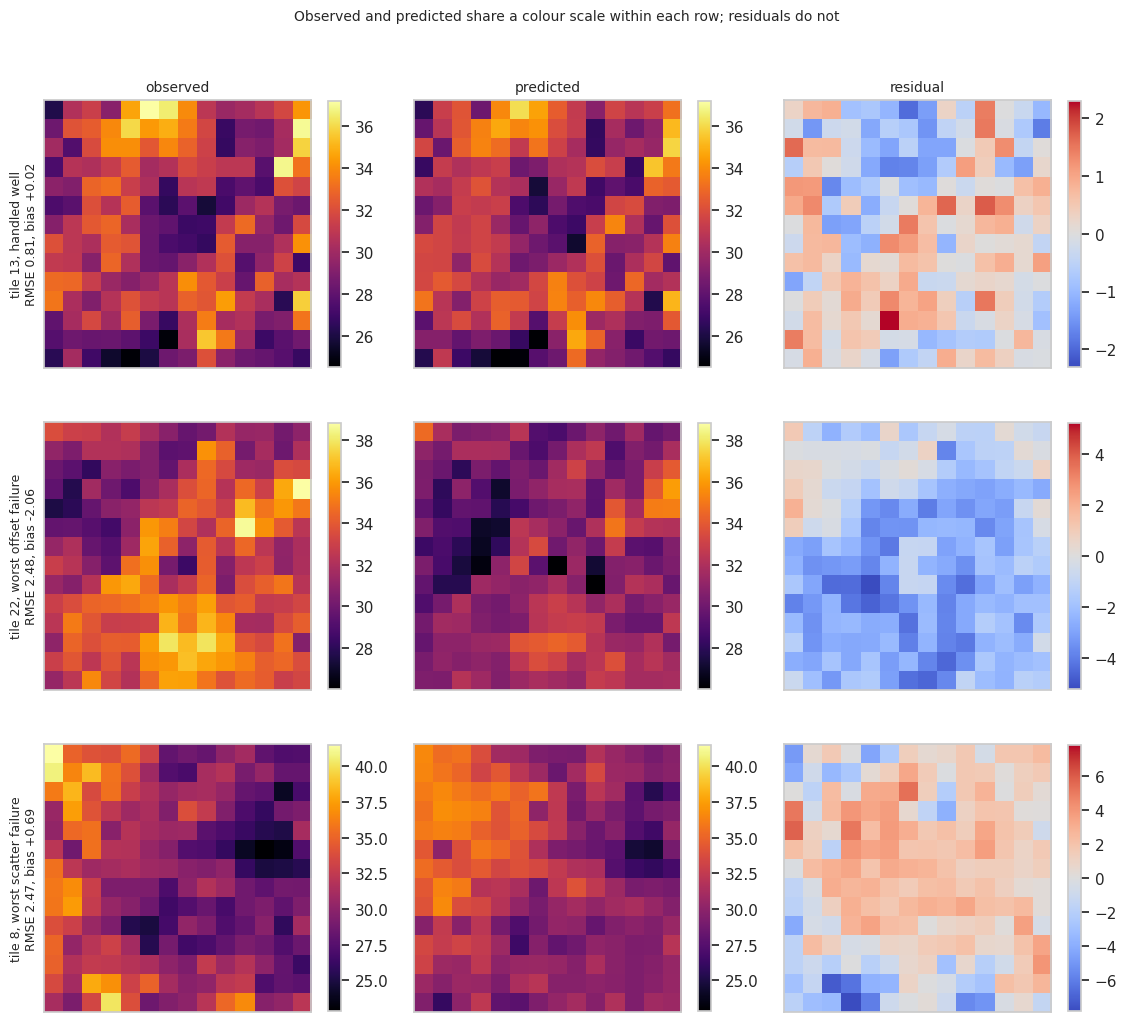

In [33]:
# Every figure so far reports error as a number. This one shows what the model actually produces
# in space, for one tile it handles well and one from each failure mode, so the two modes can be
# told apart by eye rather than only through the bias and scatter columns.
patches_with_residual["predicted"] = oof[f"pred_{BEST_CONDITION}"].values

showcase = [
    (int(tile_errors.nsmallest(1, "rmse")[GROUP_COLUMN].iloc[0]), "handled well"),
    (int(tile_errors[tile_errors.failure_mode == "offset"].nlargest(1, "rmse")[GROUP_COLUMN].iloc[0]),
     "worst offset failure"),
    (int(tile_errors[tile_errors.failure_mode == "scatter"].nlargest(1, "rmse")[GROUP_COLUMN].iloc[0]),
     "worst scatter failure"),
]

fig, axes = plt.subplots(len(showcase), 3, figsize=(11.5, 3.5 * len(showcase)))

for row, (tile_id, caption) in enumerate(showcase):
    sub = patches_with_residual[patches_with_residual[GROUP_COLUMN] == tile_id]
    stats = tile_errors[tile_errors[GROUP_COLUMN] == tile_id].iloc[0]

    def grid(column):
        g = sub.pivot(index="patch_row", columns="patch_col", values=column)
        return np.ma.masked_invalid(
            g.reindex(index=range(N_PATCH_SIDE), columns=range(N_PATCH_SIDE)).values)

    observed, predicted, residual = grid(TARGET), grid("predicted"), grid("residual")

    # Observed and predicted share one colour scale. On independent scales even a badly displaced
    # tile looks correct, because the shared pattern is all that survives normalising each panel
    # to its own range, which is exactly what an offset failure would hide.
    vmin = min(observed.min(), predicted.min())
    vmax = max(observed.max(), predicted.max())
    limit = np.abs(residual).max()

    for col, (values, title, cmap, kwargs) in enumerate([
            (observed, "observed", "inferno", dict(vmin=vmin, vmax=vmax)),
            (predicted, "predicted", "inferno", dict(vmin=vmin, vmax=vmax)),
            (residual, "residual", "coolwarm", dict(vmin=-limit, vmax=limit))]):
        ax = axes[row, col]
        im = ax.imshow(values, cmap=cmap, **kwargs)
        fig.colorbar(im, ax=ax, shrink=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        if row == 0:
            ax.set_title(title, fontsize=10)

    axes[row, 0].set_ylabel(f"tile {tile_id}, {caption}\nRMSE {stats.rmse:.2f}, "
                            f"bias {stats.bias:+.2f}", fontsize=9)

fig.suptitle("Observed and predicted share a colour scale within each row; residuals do not",
             fontsize=10, y=1.003)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "predicted_fields.png", dpi=150, bbox_inches="tight")
plt.show()

The two failure modes look different, which the error columns alone do not convey.

In the offset tile the predicted field reproduces the shape of the observed one while sitting at
the wrong level throughout, so its residual is close to a uniform sheet of one colour. In the
scatter tile the level is roughly right and the internal structure is not, so the residual
alternates sign across the tile.

Only the second is a statement about what the features resolve. The first is a consequence of
holding the tile out entirely, and no feature computed from that tile's own imagery could have
fixed it.

These are patch-level fields at the resolution of the target, not downscaled ones. The model
predicts 480 m temperature from 480 m imagery on the same dates, so it fills no gap that the
Landsat product does not already fill. Producing a continuous surface across Flanders would
describe something already directly observable, and is deliberately not attempted here.

In [34]:
# Hypothesis: the model fails on tiles whose feature distribution is unlike the training set, so
# error should rise with how far a tile sits from the dataset's centre in feature space.
# Mahalanobis distance on the three spectral indices, standardised, is the simplest test of that.
feature_matrix = patches[TRADITIONAL_FEATURES].values
scaled_features = StandardScaler().fit_transform(feature_matrix)
inverse_covariance = np.linalg.inv(np.cov(scaled_features, rowvar=False))

tile_centroids = (pd.DataFrame(scaled_features, columns=TRADITIONAL_FEATURES)
                  .assign(**{GROUP_COLUMN: patches[GROUP_COLUMN].values})
                  .groupby(GROUP_COLUMN).mean())
offsets = tile_centroids.values - scaled_features.mean(axis=0)
tile_centroids["mahalanobis"] = np.sqrt(np.einsum("ij,jk,ik->i", offsets, inverse_covariance, offsets))

tile_errors = tile_errors.merge(tile_centroids[["mahalanobis"]].reset_index(), on=GROUP_COLUMN)

candidates = {
    "distance from feature-space centre": tile_errors.mahalanobis,
    "within-tile observed sd": tile_errors.observed_sd,
    "mean NDVI": tile_errors.ndvi_mean,
    "mean NDBI": tile_errors.ndbi_mean,
    "mean albedo": tile_errors.albedo_mean,
    "patches retained": tile_errors.n_patches,
}
correlations = {label: series.corr(tile_errors.rmse) for label, series in candidates.items()}

# Thirty tiles is a small sample and six explanations are being screened at once. At n = 30 an
# unrelated variable clears |r| = 0.36 about one time in twenty, so across six of them one
# spurious pass is roughly an even bet. These numbers rule explanations out far more reliably
# than they establish them, and anything that does clear the line is a lead rather than a result.
threshold = 0.36
print(f"correlation with tile RMSE, across {len(tile_errors)} tiles")
for label, value in sorted(correlations.items(), key=lambda kv: -abs(kv[1])):
    verdict = "clears" if abs(value) >= threshold else "rejected"
    print(f"  {value:+.2f}  {verdict:8s}  {label}")

survivors = [k for k, v in correlations.items() if abs(v) >= threshold]
print(f"\n{len(candidates) - len(survivors)} of {len(candidates)} explanations rejected "
      f"at |r| >= {threshold}")

helped = int((tile_errors.rmse_gain > 0).sum())
print(f"the embedding lowered RMSE on {helped} of {len(tile_errors)} tiles, "
      f"median change {tile_errors.rmse_gain.median():+.3f} degC, "
      f"worst {tile_errors.rmse_gain.min():+.3f}, best {tile_errors.rmse_gain.max():+.3f}")

correlation with tile RMSE, across 30 tiles
  -0.44  clears    mean NDVI
  +0.24  rejected  mean NDBI
  -0.17  rejected  patches retained
  +0.15  rejected  distance from feature-space centre
  +0.09  rejected  mean albedo
  +0.06  rejected  within-tile observed sd

5 of 6 explanations rejected at |r| >= 0.36
the embedding lowered RMSE on 24 of 30 tiles, median change +0.105 degC, worst -0.184, best +0.404


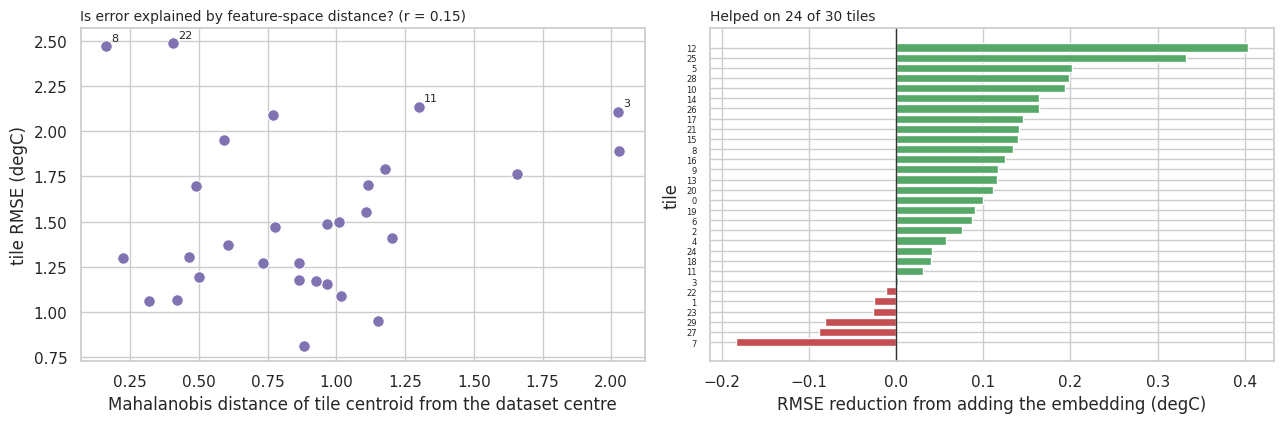

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

axes[0].scatter(tile_errors.mahalanobis, tile_errors.rmse, s=70, color="#8172B2",
                edgecolor="white", linewidth=0.8)
for _, t in tile_errors.nlargest(4, "rmse").iterrows():
    axes[0].annotate(int(t[GROUP_COLUMN]), (t.mahalanobis, t.rmse), fontsize=8,
                     xytext=(4, 4), textcoords="offset points")
axes[0].set_xlabel("Mahalanobis distance of tile centroid from the dataset centre")
axes[0].set_ylabel("tile RMSE (degC)")
axes[0].set_title(f"Is error explained by feature-space distance? "
                  f"(r = {correlations['distance from feature-space centre']:.2f})",
                  loc="left", fontsize=10)

# Where the embedding earns its place: positive means the combined model beat the spectral
# indices on that tile.
order = tile_errors.sort_values("rmse_gain")
colors = ["#C44E52" if v < 0 else "#55A868" for v in order.rmse_gain]
axes[1].barh(range(len(order)), order.rmse_gain, color=colors)
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order[GROUP_COLUMN].astype(int), fontsize=6)
axes[1].axvline(0, color="#333333", linewidth=1)
axes[1].set_xlabel("RMSE reduction from adding the embedding (degC)")
axes[1].set_ylabel("tile")
axes[1].set_title(f"Helped on {int((tile_errors.rmse_gain > 0).sum())} of "
                  f"{len(tile_errors)} tiles", loc="left", fontsize=10)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "failure_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()

The explanation this section set out to test does not hold. If the model failed on tiles whose
feature distribution was unusual, error would rise with distance from the centre of feature
space, and it does not. Nor does error track how variable a tile is, which rules out the simpler
reading that difficult tiles are just harder.

One relationship clears the line. Error falls as mean vegetation index rises, so the least
vegetated tiles are handled worst. That is readable: over built and bare surfaces, temperature is
driven by material, moisture and shading at scales the three indices do not resolve, while
vegetated surfaces sit closer to a regime those indices were designed for.

It is one lead from six screened, at a sample size where one pass by chance is roughly an even
bet, and it was not stated as a prediction before the correlations were computed. It is a
hypothesis for a future dataset, not a finding from this one.

What remains established is narrower and firmer. The largest errors are offsets rather than
scatter, the offsets are tile-level, and nothing tested here explains which tiles get them.

## 9. Final model

Cross-validation estimated how well this approach generalises. It did not produce a model to
carry forward, because each fold's model saw only four fifths of the tiles.

The model fitted here uses every tile and is the one applied to a new region in Section 10. Its
scaler is saved alongside it. A model is only reproducible together with the transformation its
inputs went through, and applying a differently fitted scaler to new data would silently shift
every feature it sees.

In [36]:
def fit_final_model():
    scaler = StandardScaler().fit(embeddings)
    features = np.hstack([patches[TRADITIONAL_FEATURES].values, scaler.transform(embeddings)])
    model = RandomForestRegressor(**RF_PARAMS).fit(features, patches[TARGET].values)
    return {"bundle": {"model": model, "scaler": scaler,
                       "condition": BEST_CONDITION,
                       "traditional_features": TRADITIONAL_FEATURES,
                       "n_tiles": int(patches[GROUP_COLUMN].nunique()),
                       "n_patches": int(len(patches)),
                       "target_range": [float(patches[TARGET].min()), float(patches[TARGET].max())]}}


bundle = cached({"bundle": MODEL_DIR / "final_combined.joblib"}, fit_final_model)["bundle"]
final_model, final_scaler = bundle["model"], bundle["scaler"]


def predict(patch_table, embedding_matrix):
    """Apply the final model to any region's patches, using the scaler fitted on Flanders."""
    features = np.hstack([patch_table[TRADITIONAL_FEATURES].values,
                          final_scaler.transform(embedding_matrix)])
    return final_model.predict(features)


# Fitted on every tile, so its training-set score is not an estimate of anything. It is printed
# only to confirm the model learned the data it was given; Section 5 holds the honest number.
in_sample = predict(patches, embeddings)
print(f"trained on {bundle['n_patches']:,} patches from {bundle['n_tiles']} tiles")
print(f"training-set R2 {r2_score(patches[TARGET], in_sample):.3f} "
      f"(not a generalisation estimate)")
print(f"cross-validated estimate from Section 5: R2 "
      f"{summary.loc[summary.condition == BEST_CONDITION, 'r2_mean'].iloc[0]:.3f}, "
      f"RMSE {summary.loc[summary.condition == BEST_CONDITION, 'rmse_mean'].iloc[0]:.3f} degC")

cached: final_combined.joblib
trained on 5,845 patches from 30 tiles
training-set R2 0.955 (not a generalisation estimate)
cross-validated estimate from Section 5: R2 0.676, RMSE 1.576 degC


## 10. Does any of this transfer to a region the model has never seen?

Question 5 from Section 1, and the reason Sections 3 and 4 were careful about what spatial
cross-validation does and does not establish. Every fold so far held out Flemish tiles from a
model trained on other Flemish tiles, under one summer composite. Tiles in this sample sit as
close as one tile width apart, so held-out is not the same as independent.

Wallonia is the other half of the same country: same satellites, same dates, same processing,
different landscape. It carries more forest and relief and less of the dense settlement pattern
that dominates Flanders. Extraction runs through the same function that built the training set,
so a difference in results cannot come from a difference in how the data was made.

Nothing is refitted. The model from Section 9 is applied as it stands, with the scaler fitted on
Flanders, which is what deploying it to a new region would actually involve.

In [37]:
N_TILES_WALLONIA = 15

wallonia = cached(
    {"patches": PROJECT_DIR / "wallonia_patches.csv",
     "embeddings": PROJECT_DIR / "wallonia_embeddings.npy"},
    lambda: extract_region("wallonia", N_TILES_WALLONIA, RANDOM_SEED),
)

wallonia_patches, wallonia_embeddings = wallonia["patches"], wallonia["embeddings"]

if len(wallonia_patches) != wallonia_embeddings.shape[0]:
    raise ValueError("row mismatch between Wallonia patches and embeddings")

print(f"{len(wallonia_patches):,} patches across "
      f"{wallonia_patches[GROUP_COLUMN].nunique()} Wallonian tiles")

comparison = pd.DataFrame({
    "Flanders (training)": [len(patches), patches[GROUP_COLUMN].nunique(),
                            patches[TARGET].mean(), patches[TARGET].std(),
                            patches[TARGET].min(), patches[TARGET].max(),
                            patches.ndvi.mean(), patches.ndbi.mean()],
    "Wallonia (unseen)": [len(wallonia_patches), wallonia_patches[GROUP_COLUMN].nunique(),
                          wallonia_patches[TARGET].mean(), wallonia_patches[TARGET].std(),
                          wallonia_patches[TARGET].min(), wallonia_patches[TARGET].max(),
                          wallonia_patches.ndvi.mean(), wallonia_patches.ndbi.mean()],
}, index=["patches", "tiles", "mean LST", "sd LST", "min LST", "max LST",
          "mean NDVI", "mean NDBI"])

print()
print(comparison.round(3).to_string())

cached: wallonia_patches.csv, wallonia_embeddings.npy
2,940 patches across 15 Wallonian tiles

           Flanders (training)  Wallonia (unseen)
patches               5845.000           2940.000
tiles                   30.000             15.000
mean LST                30.829             30.520
sd LST                   2.844              3.655
min LST                 21.297             22.355
max LST                 46.607             41.932
mean NDVI                0.614              0.635
mean NDBI               -0.182             -0.182


In [38]:
wallonia_pred = predict(wallonia_patches, wallonia_embeddings)
wallonia_truth = wallonia_patches[TARGET].values

flanders_rmse = float(np.sqrt(mean_squared_error(oof.y_true, oof[f"pred_{BEST_CONDITION}"])))
flanders_mae = float(mean_absolute_error(oof.y_true, oof[f"pred_{BEST_CONDITION}"]))
flanders_r2 = float(r2_score(oof.y_true, oof[f"pred_{BEST_CONDITION}"]))

wallonia_rmse = float(np.sqrt(mean_squared_error(wallonia_truth, wallonia_pred)))
wallonia_mae = float(mean_absolute_error(wallonia_truth, wallonia_pred))
wallonia_r2 = float(r2_score(wallonia_truth, wallonia_pred))

transfer = pd.DataFrame({
    "Flanders, out-of-fold": [flanders_rmse, flanders_mae, flanders_r2, oof.y_true.std()],
    "Wallonia, never seen": [wallonia_rmse, wallonia_mae, wallonia_r2, wallonia_truth.std()],
}, index=["RMSE (degC)", "MAE (degC)", "R2", "observed sd (degC)"])

print(transfer.round(3).to_string())
print()

# RMSE and R2 can move in opposite directions here, and if they do, RMSE is the one to trust.
# R2 is scored against the variance of the data it is computed on, so a region whose temperatures
# happen to spread more widely can return a higher R2 while every individual prediction is worse.
# Absolute error does not depend on what the target happened to do.
sd_ratio = wallonia_truth.std() / oof.y_true.std()
print(f"error change on transfer: RMSE {wallonia_rmse - flanders_rmse:+.3f} degC "
      f"({(wallonia_rmse / flanders_rmse - 1):+.1%}), MAE {wallonia_mae - flanders_mae:+.3f} degC")
print(f"R2 change: {wallonia_r2 - flanders_r2:+.3f}, against a target spread "
      f"{sd_ratio:.2f}x that of Flanders")
if (wallonia_r2 > flanders_r2) != (wallonia_rmse < flanders_rmse):
    print("the two metrics disagree; the spread of the target differs between regions, "
          "so RMSE is the one describing prediction quality here")

print(f"\nmean bias on Wallonia: {(wallonia_pred - wallonia_truth).mean():+.3f} degC")
print(f"mean bias on Flanders:  {(oof[f'pred_{BEST_CONDITION}'] - oof.y_true).mean():+.3f} degC")

                    Flanders, out-of-fold  Wallonia, never seen
RMSE (degC)                         1.580                 1.839
MAE (degC)                          1.208                 1.432
R2                                  0.691                 0.747
observed sd (degC)                  2.844                 3.655

error change on transfer: RMSE +0.259 degC (+16.4%), MAE +0.224 degC
R2 change: +0.056, against a target spread 1.29x that of Flanders
the two metrics disagree; the spread of the target differs between regions, so RMSE is the one describing prediction quality here

mean bias on Wallonia: -0.347 degC
mean bias on Flanders:  -0.005 degC


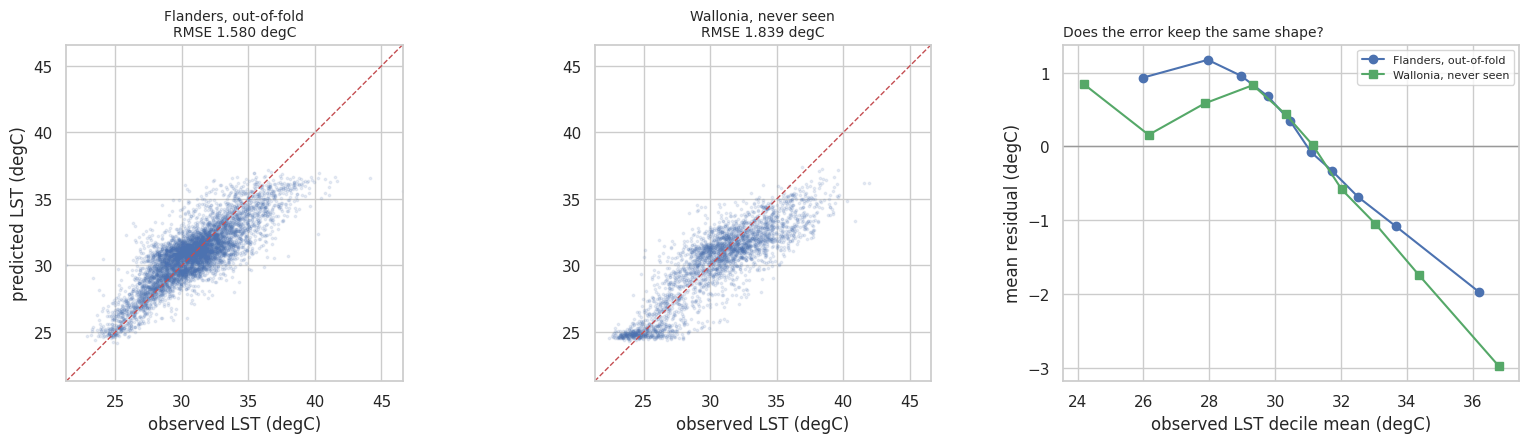

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

lo = min(oof.y_true.min(), wallonia_truth.min())
hi = max(oof.y_true.max(), wallonia_truth.max())

for ax, (truth, pred, label, rmse) in zip(axes[:2], [
        (oof.y_true.values, oof[f"pred_{BEST_CONDITION}"].values, "Flanders, out-of-fold", flanders_rmse),
        (wallonia_truth, wallonia_pred, "Wallonia, never seen", wallonia_rmse)]):
    ax.scatter(truth, pred, s=3, alpha=0.12, color="#4C72B0")
    ax.plot([lo, hi], [lo, hi], color="#C44E52", linestyle="--", linewidth=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect("equal")
    ax.set_xlabel("observed LST (degC)")
    ax.set_title(f"{label}\nRMSE {rmse:.3f} degC", fontsize=10)
axes[0].set_ylabel("predicted LST (degC)")

# Whether the error changes shape, not just size. A transfer that only shifted the level would
# show a flat offset here; one that lost resolution would fan out toward the extremes.
wallonia_deciles = pd.DataFrame({"observed": wallonia_truth,
                                 "residual": wallonia_pred - wallonia_truth})
wallonia_deciles["bin"] = pd.qcut(wallonia_deciles.observed, 10)
walloon_profile = wallonia_deciles.groupby("bin", observed=True).mean()

axes[2].axhline(0, color="#999999", linewidth=1)
axes[2].plot(by_temperature.observed, by_temperature.residual, marker="o",
             color="#4C72B0", label="Flanders, out-of-fold")
axes[2].plot(walloon_profile.observed, walloon_profile.residual, marker="s",
             color="#55A868", label="Wallonia, never seen")
axes[2].set_xlabel("observed LST decile mean (degC)")
axes[2].set_ylabel("mean residual (degC)")
axes[2].set_title("Does the error keep the same shape?", loc="left", fontsize=10)
axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "transfer.png", dpi=150, bbox_inches="tight")
plt.show()

Error rises by about a sixth on a region the model has never seen. RMSE moves from 1.58 to 1.84
degC and MAE from 1.21 to 1.43, with a systematic cold bias of about a third of a degree
appearing where Flanders had essentially none.

R² moves the other way, from 0.691 to 0.747, and it should not be read as an improvement. R² is
scored against the variance of whatever it is computed on, and temperature in this Wallonian
sample spreads 1.29 times as widely as in Flanders. A larger denominator raises R² while every
individual prediction gets worse. Reporting R² alone here would have described a model that
transferred better than it trained, which is the opposite of what happened.

The two regions are otherwise less different than the framing suggests. Mean temperature differs
by three tenths of a degree, mean NDBI is identical to three decimal places, and mean NDVI
differs by two hundredths. What changes is spread, not level. So this is a test of transfer to a
region with wider internal variation rather than to an unfamiliar climatic regime, and a sixth
of the error is what that costs.

That bounds the claim. It says something transfers across a boundary of this kind. It says
nothing about how the model would behave somewhere genuinely unlike the training data, which is
the question this design cannot reach.

## 11. Summary

Every number below is produced by the cells above, from artefacts this notebook builds. Nothing
is quoted from a previous run.

In [40]:
headline = pd.DataFrame([
    {"result": "traditional indices, cross-validated",
     "R2": summary.loc[summary.condition == "traditional", "r2_mean"].iloc[0],
     "RMSE": summary.loc[summary.condition == "traditional", "rmse_mean"].iloc[0]},
    {"result": "embedding alone, cross-validated",
     "R2": summary.loc[summary.condition == "gfm_full", "r2_mean"].iloc[0],
     "RMSE": summary.loc[summary.condition == "gfm_full", "rmse_mean"].iloc[0]},
    {"result": "both combined, cross-validated",
     "R2": summary.loc[summary.condition == "combined", "r2_mean"].iloc[0],
     "RMSE": summary.loc[summary.condition == "combined", "rmse_mean"].iloc[0]},
    {"result": "both combined, transferred to Wallonia",
     "R2": wallonia_r2, "RMSE": wallonia_rmse},
])
print(headline.round(3).to_string(index=False))

print()
print(f"dataset: {len(patches):,} patches from {patches[GROUP_COLUMN].nunique()} Flemish tiles, "
      f"{len(wallonia_patches):,} from {wallonia_patches[GROUP_COLUMN].nunique()} Wallonian tiles")
print(f"embedding lowered tile RMSE on {helped} of {len(tile_errors)} tiles "
      f"(median {tile_errors.rmse_gain.median():+.3f} degC)")
print(f"compressing the embedding to 30 components costs "
      f"{curve[(curve.condition == 'gfm_full') & (curve.n_components == GFM_DIM)].r2_mean.iloc[0] - curve[(curve.condition == 'gfm_full') & (curve.n_components == 30)].r2_mean.iloc[0]:.3f} "
      f"R2 when it is the only feature set, and almost nothing when the indices are present")

artefacts = sorted(p.relative_to(PROJECT_DIR) for p in PROJECT_DIR.rglob("*") if p.is_file())
print(f"\n{len(artefacts)} artefacts written to {PROJECT_DIR}")
for a in artefacts:
    print(f"  {a}")

                                result    R2  RMSE
  traditional indices, cross-validated 0.635 1.671
      embedding alone, cross-validated 0.662 1.614
        both combined, cross-validated 0.676 1.576
both combined, transferred to Wallonia 0.747 1.839

dataset: 5,845 patches from 30 Flemish tiles, 2,940 from 15 Wallonian tiles
embedding lowered tile RMSE on 24 of 30 tiles (median +0.105 degC)
compressing the embedding to 30 components costs 0.123 R2 when it is the only feature set, and almost nothing when the indices are present

25 artefacts written to /content/drive/MyDrive/GFM_LST_Flanders
  embeddings.npy
  environment.json
  figures/adjacent_tiles.png
  figures/benchmark_scatter.png
  figures/data_overview.png
  figures/failure_diagnosis.png
  figures/fold_map.png
  figures/pca_ablation.png
  figures/predicted_fields.png
  figures/tile_errors.png
  figures/tile_examples.png
  figures/tile_map.png
  figures/transfer.png
  figures/worst_tiles.png
  flanders_manifest.json
  models

### The five questions

**Can frozen embeddings predict patch-level temperature?** Yes, and on their own they beat three
purpose-built spectral indices, though not by much.

**Do they outperform the traditional indices?** On average, marginally. The more useful answer is
that they change consistency more than level: fold-to-fold variability falls by close to half,
and the gain is largest on the fold where the indices do worst. A frozen general-purpose backbone
with no thermal training holds performance up where hand-designed thermal proxies become
unreliable.

**Does combining them help?** Yes, on every fold, but the margins are small enough that the
direction of the result is better supported than its size.

**Does PCA help?** No, and the way it fails is informative. The embedding alone loses a large
share of its predictive value under compression and does not recover it by retaining more
components, which points at rotation rather than at information loss: a Random Forest splits one
coordinate at a time, and PCA spreads the signal across coordinates. The combined condition is
nearly flat across the whole sweep, so reading only that curve would suggest the embedding
compresses cheaply, which it does not.

**Does it transfer?** Partly. Error rises about a sixth in a region never seen, with a small cold
bias appearing. The two regions turn out to differ mainly in spread rather than in level, so this
bounds the claim to transfer across a modest boundary.

### Limitations

**Thirty tiles.** Patch counts run into the thousands, but patches inside a tile are not
independent, so the effective sample for anything spatial is thirty. Every correlation in
Section 8 rests on that, which is why five of six candidate explanations could be rejected while
the one that survived is described as a lead rather than a finding.

**No significance test is reported.** With five folds there are five paired observations, and
K-fold training sets overlap in most of their rows, so the spread across folds understates the
true variability and a t-test built on it returns a p-value that is too small. Win counts and
worst-fold margins are reported instead.

**Held out is not independent.** Tile centres in this sample come as close as one tile width, so
two tiles sit edge to edge. Grouping on tile removes the largest form of leakage without making
test tiles independent of training tiles.

**One season, one country.** A single summer composite over Belgium. Nothing here speaks to other
seasons, other climates, or years in which the compositing window behaves differently.

**The PCA result is about this learner.** The rotation argument applies to axis-aligned splitting.
A model that is rotation-invariant would likely show a different curve, and no such model was
tested.

**The vegetation lead was not predicted in advance.** It emerged from six correlations screened
at once on thirty tiles, where one pass by chance is roughly an even bet. It is a hypothesis for
a future dataset.

### Reproducing this

Run the notebook against an empty directory. Extraction needs an Earth Engine project id in
`GEE_PROJECT` and takes roughly half an hour per region on a GPU runtime; everything after it
runs on CPU in minutes. With `patches.csv` and `embeddings.npy` already present, no Earth Engine
access is needed at all. `FORCE_RECOMPUTE = True` in Section 0 rebuilds every cached artefact.